In [1]:
# ======================================================================
# EMS 異常檢測系統 — 完整版 v5（本機 Jupyter / .ipynb 版本，SOC 來源修正版）
# ----------------------------------------------------------------------
#   ★ v5 更動（整合邱老師實驗室同後台、已驗證可讀到 SOC 的連線方式）：
#   SOC 改從「儲能主機」192.168.1.200:502、FC03 位址 199 讀取，取代原本連
#   不上的 EMS（192.168.1.204:2000）。邱老師實驗室同學是透過 VPN 連進同一套
#   後台，其餘設定與本檔相同，其 ems_other_laboratory_renew.py 已驗證這組
#   位址可穩定讀到 SOC。EMS 相關程式碼原封不動保留、預設停用，之後排查通了
#   只要把 EMS_CFG['enabled'] 改回 True，讀到的值會優先覆蓋。
# ----------------------------------------------------------------------
#   【階段一】離線訓練：讀歷史 CSV + 混搭模擬異常 → 訓練 Hybrid(IF+RF/XGB) +
#            多分類診斷模型 → 存檔（joblib）
#   【階段二】線上即時運行：pymodbus 讀現場 Modbus TCP 端點 → 用階段一
#            訓練好的模型推論 → 寫回 Firebase（Dashboard 自動更新）
#
# ★ 本版（v4）根據現場實際 Modbus 診斷結果做的修正：
#   1) 主表 / 儲能電表暫存器位址修正為 Acuvim II 手冊的
#      FC03、0x4022~0x4023、float32（原本 v3 用的 0x4006 + FC04 是錯的佔位值）。
#      現場實測：主表 88.13 kW、儲能電表 -0.637 kW，且跟現場儀表板數字吻合。
#   2) 確認「儲能電表」量到的 Psum 就是 ESS 功率本身（不是另一組負載），
#      調節後負載改用 before_load - ess_power 現場運算得出，
#      不再需要從 EMS 額外讀一次 ess_power。
#      （已用現場儀表板截圖數字交叉驗證：90.06 - (-0.63) = 90.69，兩邊對得上）
#   3) EMS（192.168.1.204:2000）目前現場連線異常：TCP 連得上，但標準 Modbus TCP
#      請求完全沒有回應；改用 RTU framer 測試時，設備會在 ~25ms 內主動關閉連線，
#      代表設備確實有在解析封包但拒絕/不認得這組請求 —— 高度懷疑是 unit_id
#      或暫存器位址跟這台實際設備不符，而非單純網路/硬體故障。
#      在排查出正確參數前，EMS 預設停用（EMS_CFG['enabled'] = False），
#      SOC / SOH 會明確標記為 EMS_DISABLED，不會偷偷補 0 或沿用上一筆冒充。
#   4) 移除「Modbus 讀取失敗時沿用上一筆資料」的行為：讀取失敗一律標記狀態
#      （BAD / EMS_DISABLED），絕不用舊資料或 0 冒充本次量測。
#   5) 新增【執行區塊：Modbus 診斷】，開始長時間輪詢 / 寫 Firebase 之前，
#      先用這一格單獨測試 TCP + Modbus 是否正常，不需要模型、不需要 Firebase。
#   6) 離線訓練 use_synthetic_diagnostic_features 預設改為 False：
#      正式現場模型預設只用真實欄位（before_load/after_load/contract_capacity/
#      ess_power/soc）衍生特徵；SOC 仍然需要 EMS 才有現場即時值，若 EMS 沒打開，
#      即時異常偵測模組會明確標記為「本輪略過」，不會假造 SOC。
#      如需研究對照，請用 run_ablation_comparison()。
#
# ⚠ 這份是「現場 Modbus 診斷版」修正，主表/儲能電表的讀值路徑已用現場
#   數值交叉驗證過，可信；EMS 讀值路徑仍待現場排查 unit_id / 位址後再啟用。
# ======================================================================


## ⚡ 快速恢復（Kernel 重開後，模型已經訓練過，只要跑這一格）

**如果你是第一次執行、或想重新訓練模型**：跳過這格，直接往下照順序（安裝套件 → ... →
【階段一】離線訓練 → 【階段二】即時運行）跑。訓練只需要成功做過一次，之後不用每次都重跑。

**如果你只是 kernel 重開、重新整理瀏覽器、電腦重開機，但模型已經訓練好、`ems_model_bundle.joblib`
這個檔案已經存在**：不用再回頭跑 CSV 載入、特徵工程、訓練那些格（很花時間），
只要確定 `ems_realtime_lib.py` 這個檔案跟這份 notebook放在**同一個資料夾**，
執行下面這一格就好，會直接跳到可以開始即時監測的狀態。


In [2]:
from ems_realtime_lib import *

model_bundle = joblib.load(MODEL_BUNDLE_PATH)
print(f"✓ 已載入已訓練模型: {MODEL_BUNDLE_PATH}")

# 之後要接 Firebase 才需要跑這行；只想先看 Modbus 數據可以先跳過
# ref = init_firebase(FIREBASE_CRED_JSON_PATH)

print("✓ 快速恢復完成，可以直接跳到下面的「Modbus 現場診斷」或「階段二：線上即時運行」執行")


✓ 已載入已訓練模型: c:\Users\zoe97\OneDrive\Desktop\260916數位孿生目前最終版計劃案代碼\ems_model_bundle.joblib
✓ 快速恢復完成，可以直接跳到下面的「Modbus 現場診斷」或「階段二：線上即時運行」執行


## 第一段：安裝套件與環境導入
第一次在這台電腦上執行時，取消下一行的註解來安裝套件（之後可以註解掉）。

In [3]:
%pip install firebase-admin pandas numpy scikit-learn matplotlib seaborn imbalanced-learn xgboost psutil pymodbus joblib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\zoe97\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from collections import deque
import glob
import os
import re
import time
import psutil
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import (precision_score, recall_score, f1_score,
                            accuracy_score, confusion_matrix, classification_report,
                            roc_curve, auc, precision_recall_curve)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 中文字型：Windows 常見中文字型優先，其餘平台 fallback
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 套件載入完成")

✓ 套件載入完成


## 第二段：Firebase 初始化函數（本機版）
原本 Colab 版本用 `google.colab.files.upload()` 跳出上傳視窗選金鑰檔，
本機 Jupyter 沒有這個功能，改成直接指定金鑰 JSON 檔案的路徑。

請把下面 `FIREBASE_CRED_JSON_PATH` 改成你自己下載的 Firebase 服務帳號金鑰 JSON 檔路徑，
例如：`r"C:\Users\User\Desktop\firebase-key.json"`

In [5]:
FIREBASE_CRED_JSON_PATH = r"C:\Users\zoe97\OneDrive\Desktop\260916數位孿生目前最終版計劃案代碼\essssimulation3-firebase-adminsdk-fbsvc-0d8253860b.json"  # ← 改成你自己的金鑰路徑
FIREBASE_DATABASE_URL = 'https://essssimulation3-default-rtdb.asia-southeast1.firebasedatabase.app/'

In [6]:
def init_firebase(cred_json_path=None, database_url=FIREBASE_DATABASE_URL):
    """
    本機版初始化：不再跳出瀏覽器上傳視窗，改成直接讀取本機的金鑰 JSON 檔路徑。
    """
    print("\n=== Firebase 初始化 ===")
    import firebase_admin
    from firebase_admin import credentials, db

    try:
        app = firebase_admin.get_app()
        print("⚠ Firebase 已經初始化，刪除舊連接...")
        firebase_admin.delete_app(app)
    except ValueError:
        pass

    if cred_json_path is None:
        cred_json_path = FIREBASE_CRED_JSON_PATH

    cred_path = Path(cred_json_path)
    if not cred_path.exists():
        raise FileNotFoundError(
            f"找不到 Firebase 金鑰檔案: {cred_path}\n"
            f"請先把 FIREBASE_CRED_JSON_PATH 改成你實際的金鑰 JSON 檔案路徑。"
        )

    with open(cred_path, 'r', encoding='utf-8') as f:
        cred_data = json.load(f)
        project_id = cred_data.get('project_id', 'your-project-id')

    cred = credentials.Certificate(str(cred_path))

    print(f"📊 專案 ID: {project_id}")
    print(f"🔗 資料庫 URL: {database_url}")

    firebase_admin.initialize_app(cred, {'databaseURL': database_url})
    print("✓ Firebase 連接成功!")
    return db.reference()


def clear_firebase_data(ref):
    print("\n=== 清除Firebase舊數據 ===")
    all_data = ref.get()
    if all_data is None:
        print("✓ Firebase 中沒有數據")
        return
    nodes = list(all_data.keys()) if isinstance(all_data, dict) else []
    if nodes:
        for node in nodes:
            ref.child(node).delete()
        print(f"✓ 已刪除 {len(nodes)} 個舊節點")


def upload_to_firebase(ref, df, batch_size=500):
    """
    批次寫入：先在記憶體組好「相對於 ems_data 節點」的巢狀字典
    （key 用 'date/time' 表示路徑），再分批呼叫 ems_data_ref.update(batch)，
    一次送出一批，大幅減少 HTTP 往返次數。
    """
    print("\n=== 上傳數據到 Firebase（批次寫入）===")
    COLS = ['ess_power', 'soc', 'soh', 'cell_v_diff', 'self_discharge_rate',
            'contract_capacity', 'before_load', 'after_load', 'over_contract',
            'is_anomaly', 'anomaly_type']

    ems_data_ref = ref.child('ems_data')
    total = len(df)
    batch = {}
    uploaded = 0

    for _, row in df.iterrows():
        record = {'timestamp': row['timestamp'].isoformat()}
        for col in COLS:
            record[col] = row[col] if col in row.index else 0
        batch[f"{row['date']}/{row['time']}"] = record

        if len(batch) >= batch_size:
            ems_data_ref.update(batch)
            uploaded += len(batch)
            print(f"  ✓ 已上傳 {uploaded}/{total} 筆")
            batch = {}

    if batch:
        ems_data_ref.update(batch)
        uploaded += len(batch)
        print(f"  ✓ 已上傳 {uploaded}/{total} 筆")

    print(f"✓ 上傳完成，共 {uploaded} 筆")

    first_date = df['date'].iloc[0]
    first_time = df['time'].iloc[0]
    ref.update({'viewerDate': first_date, 'viewerTime': first_time})
    print(f"✓ 已初始化 viewerDate={first_date}, viewerTime={first_time}")


def upload_single_record_to_firebase(ref, record: dict):
    """
    階段二即時推論用：只上傳『這一筆』最新資料，並同步更新 viewer 指標。

    ★ 修正：record['timestamp'] 是 datetime 物件，Firebase REST API 底層用
      json.dumps 序列化時不認得 datetime，會丟 TypeError。這裡另外複製一份
      要上傳的字典，把 timestamp 轉成字串，不動原本 record（buffer 裡的
      resample 還是需要真正的 datetime）。
    """
    date_key = record['date']
    time_key = record['time']

    record_to_send = dict(record)
    ts = record_to_send.get('timestamp')
    if hasattr(ts, 'isoformat'):
        record_to_send['timestamp'] = ts.isoformat()

    ref.child('ems_data').child(date_key).child(time_key).set(record_to_send)
    ref.update({'viewerDate': date_key, 'viewerTime': time_key})

## 第三段：讀取歷史 CSV
中原大學 102kWh 儲能系統場域運轉資訊，每日一個檔案，1 分鐘一筆，UTF-8 BOM 編碼。
欄位：資料時間 / 調度前(原始負載)(kW) / 調節後負載(kW) / 契約容量 (kW) / ESS功率(kW) / SOC(%)

In [7]:
def load_historical_csv(folder_path, resample_to='15min'):
    """
    讀取資料夾內全部歷史 CSV，組合成單一 DataFrame。
    resample_to: 若不是 None，會把 1 分鐘資料降採樣成指定頻率的平均值
                 （原特徵工程的滑動視窗 [4,8,12,24] 是以 15 分鐘為單位設計，
                   所以預設先重採樣成 15 分鐘，維持跟原本模擬資料一致的時間刻度）
    """
    print(f"\n=== 讀取歷史 CSV：{folder_path} ===")
    files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
    print(f"  找到 {len(files)} 個檔案")

    col_map = {
        '資料時間': 'timestamp',
        '調度前(原始負載)(kW)': 'before_load',
        '調節後負載(kW)': 'after_load',
        '契約容量 (kW)': 'contract_capacity',
        'ESS功率(kW)': 'ess_power',
        'SOC(%)': 'soc',
    }

    frames = []
    skipped = 0
    for fp in files:
        try:
            df_day = pd.read_csv(fp, encoding='utf-8-sig')
        except Exception as e:
            print(f"  ⚠ 讀取失敗，略過: {os.path.basename(fp)} ({e})")
            skipped += 1
            continue

        if df_day.empty or '資料時間' not in df_day.columns:
            skipped += 1
            continue

        df_day = df_day.rename(columns=col_map)
        needed = ['timestamp', 'before_load', 'after_load', 'contract_capacity', 'ess_power', 'soc']
        missing = [c for c in needed if c not in df_day.columns]
        if missing:
            print(f"  ⚠ {os.path.basename(fp)} 缺欄位 {missing}，略過")
            skipped += 1
            continue

        frames.append(df_day[needed])

    if not frames:
        raise RuntimeError("沒有任何一個歷史 CSV 讀取成功，請確認資料夾路徑與檔案內容")

    df = pd.concat(frames, ignore_index=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    for c in ['before_load', 'after_load', 'contract_capacity', 'ess_power', 'soc']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['timestamp']).sort_values('timestamp').drop_duplicates(subset='timestamp')
    df = df.dropna(subset=['before_load', 'after_load', 'soc'])

    if resample_to:
        NUMERIC_COLS = ['before_load', 'after_load', 'contract_capacity', 'ess_power', 'soc']
        df = (df.set_index('timestamp')
                .resample(resample_to)
                .mean(numeric_only=True)
                .dropna(subset=NUMERIC_COLS)
                .reset_index())

    df['over_contract'] = (df['after_load'] - df['contract_capacity']).clip(lower=0)
    df['date'] = df['timestamp'].dt.strftime('%Y-%m-%d')
    df['time'] = df['timestamp'].dt.strftime('%H:%M')

    print(f"✓ 歷史資料讀取完成：{len(df)} 筆（略過 {skipped} 個檔案）")
    print(f"  時間範圍：{df['timestamp'].min()} ~ {df['timestamp'].max()}")
    print(f"  平均契約容量：{df['contract_capacity'].mean():.1f} kW（現場實際簽約值）")

    n_nan = df[['before_load', 'after_load', 'contract_capacity', 'ess_power', 'soc']].isna().sum().sum()
    if n_nan > 0:
        print(f"  ⚠ 警告：讀取後仍偵測到 {n_nan} 個 NaN（不應發生，請檢查資料源）")

    return df

## 第三段之二：真實資料 × 模擬異常「混搭」

In [8]:
def augment_real_data_with_synthetic_anomalies(df_real, anomaly_rate=0.08, seed=42):
    """
    把讀進來的『真實』場域資料（負載/ESS功率/SOC）當作正常運轉的基底，
    在上面疊加『模擬』的三種電池診斷異常與診斷特徵（SOH、cell 電壓差、
    自放電率），因為現場 CSV 匯出檔本身沒有這些感測值。
    """
    np.random.seed(seed)
    df = df_real.copy().reset_index(drop=True)
    n = len(df)

    soh = 100.0
    is_anomaly = np.zeros(n, dtype=int)
    anomaly_type = np.array(['normal'] * n, dtype=object)
    cell_v_diff = np.zeros(n)
    self_discharge_rate = np.zeros(n)
    soh_arr = np.zeros(n)

    ess_power = df['ess_power'].to_numpy(dtype=float).copy()
    soc = df['soc'].to_numpy(dtype=float).copy()

    for i in range(n):
        cell_v_diff[i] = 0.01 + np.random.normal(0, 0.002)
        self_discharge_rate[i] = 0.002

        anomaly = np.random.random() < anomaly_rate
        atype = 'normal'

        if anomaly:
            r = np.random.random()
            if r < 0.33:
                atype = 'cell_inconsistency'
                cell_v_diff[i] = np.random.uniform(0.08, 0.15)
            elif r < 0.67:
                atype = 'internal_short'
                self_discharge_rate[i] = np.random.uniform(0.40, 0.60)
            else:
                atype = 'soh_degradation'
                soh = max(60, soh - np.random.uniform(0.5, 2.0))
                soc[i] = max(0, soc[i] - np.random.uniform(1, 5))

        if atype == 'normal':
            soh = max(60, soh - 0.0001)

        is_anomaly[i] = int(anomaly)
        anomaly_type[i] = atype
        soh_arr[i] = soh

    df['ess_power'] = ess_power
    df['soc'] = np.clip(soc, 0, 100)
    df['soh'] = np.round(soh_arr, 2)
    df['cell_v_diff'] = np.round(cell_v_diff, 4)
    df['self_discharge_rate'] = np.round(self_discharge_rate, 4)
    df['is_anomaly'] = is_anomaly
    df['anomaly_type'] = anomaly_type
    df['over_contract'] = (df['after_load'] - df['contract_capacity']).clip(lower=0)

    print(f"\n✓ 混搭完成：{len(df)} 筆（真實負載/SOC/ESS功率 + 模擬電池診斷異常）")
    print(f"  異常率: {df['is_anomaly'].mean()*100:.2f}%")
    print("\n異常類型分布:")
    for atype_, cnt in df['anomaly_type'].value_counts().items():
        print(f"  {atype_:22s}: {cnt:5d} 筆 ({cnt/len(df)*100:.1f}%)")

    return df

## 第五段：進階特徵工程

In [9]:
def engineer_features_advanced(df, window_sizes=[4, 8, 12, 24]):
    print(f"\n=== 進階特徵工程 ===")
    print(f"  滑動視窗大小: {window_sizes}")
    df_p = df.copy()

    df_p['hour']         = df_p['timestamp'].dt.hour
    df_p['day_of_week']  = df_p['timestamp'].dt.dayofweek
    df_p['is_weekend']   = (df_p['day_of_week'] >= 5).astype(int)
    df_p['is_peak_hour'] = ((df_p['hour'] >= 9) & (df_p['hour'] <= 17)).astype(int)
    df_p['is_night']     = ((df_p['hour'] >= 22) | (df_p['hour'] <= 6)).astype(int)
    df_p['is_daytime']   = ((df_p['hour'] >= 6)  & (df_p['hour'] <= 18)).astype(int)
    df_p['hour_sin']     = np.sin(2*np.pi*df_p['hour']/24)
    df_p['hour_cos']     = np.cos(2*np.pi*df_p['hour']/24)
    df_p['day_sin']      = np.sin(2*np.pi*df_p['day_of_week']/7)
    df_p['day_cos']      = np.cos(2*np.pi*df_p['day_of_week']/7)

    df_p['cell_v_diff_ma']   = df_p['cell_v_diff'].rolling(4,  min_periods=1).mean()
    df_p['cell_v_diff_std']  = df_p['cell_v_diff'].rolling(8,  min_periods=1).std().fillna(0)
    df_p['cell_v_diff_max']  = df_p['cell_v_diff'].rolling(12, min_periods=1).max()
    df_p['cell_v_high_flag'] = (df_p['cell_v_diff'] > 0.05).astype(int)

    df_p['self_dis_ma']   = df_p['self_discharge_rate'].rolling(4, min_periods=1).mean()
    df_p['self_dis_std']  = df_p['self_discharge_rate'].rolling(8, min_periods=1).std().fillna(0)
    df_p['self_dis_high'] = (df_p['self_discharge_rate'] > 0.05).astype(int)

    df_p['soh_diff']        = df_p['soh'].diff().fillna(0)
    df_p['soh_low_flag']    = (df_p['soh'] < 80).astype(int)
    df_p['soh_soc_interact'] = df_p['soh'] * df_p['soc'] / 10000.0
    df_p['soc_change_rate'] = df_p['soc'].diff().fillna(0) / 0.25
    df_p['dv_dq_proxy']     = df_p['soc_change_rate'].abs() / (df_p['ess_power'].abs() + 1e-6)

    df_p['soc_diff']    = df_p['soc'].diff().fillna(0)
    df_p['soc_diff2']   = df_p['soc_diff'].diff().fillna(0)
    df_p['power_diff']  = df_p['ess_power'].diff().fillna(0)
    df_p['power_diff2'] = df_p['power_diff'].diff().fillna(0)
    df_p['load_diff']   = df_p['before_load'].diff().fillna(0)

    for w in window_sizes:
        df_p[f'soc_mean_{w}']   = df_p['soc'].rolling(w, min_periods=1).mean()
        df_p[f'soc_std_{w}']    = df_p['soc'].rolling(w, min_periods=1).std().fillna(0)
        df_p[f'soc_range_{w}']  = (df_p['soc'].rolling(w, min_periods=1).max() -
                                    df_p['soc'].rolling(w, min_periods=1).min())
        df_p[f'power_mean_{w}'] = df_p['ess_power'].rolling(w, min_periods=1).mean()
        df_p[f'power_std_{w}']  = df_p['ess_power'].rolling(w, min_periods=1).std().fillna(0)
        df_p[f'load_std_{w}']   = df_p['before_load'].rolling(w, min_periods=1).std().fillna(0)

    df_p['power_to_load_ratio']   = df_p['ess_power']    / (df_p['before_load'] + 1e-6)
    df_p['soc_power_interaction'] = df_p['soc']          * df_p['ess_power']
    df_p['load_reduction_rate']   = (df_p['before_load'] - df_p['after_load']) / (df_p['before_load'] + 1e-6)
    df_p['contract_violation']    = (df_p['after_load']  > df_p['contract_capacity']).astype(int)
    df_p['over_contract_ratio']   = df_p['over_contract'] / (df_p['contract_capacity'] + 1e-6)
    df_p['soc_extreme']           = ((df_p['soc'] < 10) | (df_p['soc'] > 95)).astype(int)
    df_p['power_extreme']         = (np.abs(df_p['ess_power']) > 200).astype(int)
    df_p['power_volatility']      = df_p['ess_power'].rolling(8, min_periods=1).std().fillna(0)

    for lag in [1, 2, 4]:
        df_p[f'soc_lag_{lag}']   = df_p['soc'].shift(lag).bfill()
        df_p[f'power_lag_{lag}'] = df_p['ess_power'].shift(lag).bfill()

    print(f"✓ 特徵工程完成，總欄數: {df_p.shape[1]}")
    return df_p


SYNTHETIC_ONLY_RAW_COLS = ['soh', 'cell_v_diff', 'self_discharge_rate']

SYNTHETIC_ONLY_ENGINEERED_COLS = [
    'cell_v_diff_ma', 'cell_v_diff_std', 'cell_v_diff_max', 'cell_v_high_flag',
    'self_dis_ma', 'self_dis_std', 'self_dis_high',
    'soh_diff', 'soh_low_flag', 'soh_soc_interact',
]
# 注意：soc_change_rate / dv_dq_proxy 只用到 soc 與 ess_power（都是真實欄位），
# 不放進排除清單。


def select_features_for_if(df_processed, use_synthetic_diagnostic_features=True):
    """
    use_synthetic_diagnostic_features:
      True（預設）：使用全部特徵，含模擬電池診斷特徵。
      False（對照實驗）：排除模擬電池診斷特徵（soh, cell_v_diff,
      self_discharge_rate 及其衍生欄位），只留下由真實現場欄位
      （before_load/after_load/contract_capacity/ess_power/soc）
      衍生的特徵，得到不依賴模擬感測值的基準指標。
    """
    exclude_cols = ['timestamp', 'date', 'time', 'is_anomaly', 'anomaly_type']
    if not use_synthetic_diagnostic_features:
        exclude_cols = exclude_cols + SYNTHETIC_ONLY_RAW_COLS + SYNTHETIC_ONLY_ENGINEERED_COLS

    feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
    mode_str = "含模擬電池診斷特徵（原始模式）" if use_synthetic_diagnostic_features else "僅真實欄位衍生特徵（對照實驗基準）"
    print(f"  選擇特徵數: {len(feature_cols)} ({mode_str})")
    return feature_cols


def clean_nan_inf(df_processed, feature_cols):
    """
    NaN / Inf 安全網。
    在特徵工程之後、切 X/y 之前呼叫，先用 ffill/bfill 補值，
    仍殘留 NaN 的整列直接捨棄（極少數，通常是資料開頭的邊界情況）。
    """
    n_before = len(df_processed)
    df_clean = df_processed.copy()
    df_clean[feature_cols] = (
        df_clean[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .ffill()
        .bfill()
    )
    df_clean = df_clean.dropna(subset=feature_cols).reset_index(drop=True)
    n_after = len(df_clean)
    if n_after < n_before:
        print(f"  ⚠ NaN/Inf 安全網：捨棄 {n_before - n_after} 筆殘留缺失值的資料")
    else:
        print(f"  ✓ NaN/Inf 安全網：無殘留缺失值")
    return df_clean

## 第六段：特徵選擇

In [10]:
def find_optimal_k_features(X, y, feature_names, k_range=None, plot=True):
    print("\n" + "="*70)
    print("   自動特徵數量優化 (肘部法則)")
    print("="*70)

    if k_range is None:
        max_k = min(50, X.shape[1])
        k_range = list(range(5, max_k + 1, 5))

    val_size = int(len(X) * 0.2)
    X_train_temp = X[:-val_size]
    y_train_temp = y[:-val_size]
    X_val_temp   = X[-val_size:]
    y_val_temp   = y[-val_size:]

    f1_scores = []
    print(f"\n測試特徵數量範圍: {k_range}")
    for k in k_range:
        selector = SelectKBest(mutual_info_classif, k=min(k, X.shape[1]))
        X_train_selected = selector.fit_transform(X_train_temp, y_train_temp)
        X_val_selected   = selector.transform(X_val_temp)

        model = RandomForestClassifier(
            n_estimators=100, max_depth=10, class_weight='balanced',
            random_state=42, n_jobs=-1
        )
        model.fit(X_train_selected, y_train_temp)
        y_pred = model.predict(X_val_selected)
        f1 = f1_score(y_val_temp, y_pred, zero_division=0)
        f1_scores.append(f1)
        print(f"  k={k:2d}: F1={f1:.4f}")

    if len(f1_scores) >= 3:
        f1_arr    = np.array(f1_scores)
        f1_smooth = np.convolve(f1_arr, np.ones(3)/3, mode='same')
        f1_smooth[0]  = f1_arr[0]
        f1_smooth[-1] = f1_arr[-1]

        gains     = np.diff(f1_smooth)
        max_gain  = gains.max() if gains.max() > 0 else 1e-6
        threshold = max(0.003, max_gain * 0.15)
        saturated = np.where(gains < threshold)[0]

        if len(saturated) > 0:
            sat_start  = saturated[0] + 1
            candidates = list(range(sat_start, len(k_range)))
            optimal_k  = k_range[candidates[int(np.argmax(f1_arr[candidates]))]]
            method_used = f'邊際收益飽和（門檻={threshold:.4f}）'
        else:
            optimal_k   = k_range[int(np.argmax(f1_smooth))]
            method_used = 'F1最高點（收益持續顯著）'

        best_f1  = f1_arr[k_range.index(optimal_k)]
        first_f1 = f1_arr[0]
        if optimal_k == k_range[-1] and (best_f1 - first_f1) < 0.005:
            optimal_k   = k_range[0]
            method_used = '簡約原則（最大k無明顯優勢）'

        print(f'\n  選擇方法: {method_used}')
    else:
        optimal_k = k_range[int(np.argmax(f1_scores))]

    print(f"\n✓ 最佳特徵數量: k={optimal_k} (F1={f1_scores[k_range.index(optimal_k)]:.4f})")

    if plot:
        plt.figure(figsize=(10, 6))
        plt.plot(k_range, f1_scores, 'bo-', linewidth=2, markersize=8, label='F1 Score')
        plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
                   label=f'Optimal k={optimal_k}')
        plt.xlabel('Number of Features (k)', fontweight='bold', fontsize=12)
        plt.ylabel('F1 Score', fontweight='bold', fontsize=12)
        plt.title('Elbow Method for Optimal Feature Selection', fontweight='bold', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=11)
        plt.tight_layout()
        plt.savefig('feature_selection_elbow.png', dpi=300, bbox_inches='tight')
        print("✓ 肘部圖已保存: feature_selection_elbow.png")
        plt.show()

    return optimal_k


def select_best_features(X, y, feature_names, k=None, auto_k=True):
    if k is None and auto_k:
        k = find_optimal_k_features(X, y, feature_names)
    elif k is None:
        k = 30

    print(f"\n=== 特徵選擇 (保留前 {k} 個) ===")
    selector = SelectKBest(mutual_info_classif, k=min(k, X.shape[1]))
    X_selected = selector.fit_transform(X, y)
    selected_indices = selector.get_support(indices=True)
    selected_features = [feature_names[i] for i in selected_indices]

    scores = selector.scores_[selected_indices]
    feature_scores = sorted(zip(selected_features, scores), key=lambda x: x[1], reverse=True)

    print(f"✓ 選擇 {len(selected_features)} 個特徵")
    print("\n前5個最重要特徵:")
    for feat, score in feature_scores[:5]:
        print(f"  {feat}: {score:.4f}")

    return X_selected, selected_features, selected_indices

## 第七段：自動化參數尋優

In [11]:
def optimize_isolation_forest(X_train, y_train, X_val, y_val):
    print("\n=== Isolation Forest 參數優化 ===")
    param_grid = {
        'n_estimators' : [100, 200],
        'max_samples'  : [256, 512],
        'contamination': [0.05, 0.08, 0.12],
        'max_features' : [0.1, 0.15, 0.2, 0.3]
    }
    best_score, best_params, results_log = 0, {}, []
    total_combinations = (len(param_grid['n_estimators']) * len(param_grid['max_samples']) *
                          len(param_grid['contamination']) * len(param_grid['max_features']))
    print(f"  總共測試 {total_combinations} 種參數組合...")

    count = 0
    for n_est in param_grid['n_estimators']:
        for max_samp in param_grid['max_samples']:
            for contam in param_grid['contamination']:
                for max_feat in param_grid['max_features']:
                    count += 1
                    model = IsolationForest(n_estimators=n_est, max_samples=max_samp,
                                             contamination=contam, max_features=max_feat,
                                             random_state=42, n_jobs=-1)
                    model.fit(X_train)
                    y_pred = np.where(model.predict(X_val) == -1, 1, 0)
                    f1 = f1_score(y_val, y_pred, zero_division=0)
                    results_log.append({'n_estimators': n_est, 'max_samples': max_samp,
                                         'contamination': contam, 'max_features': max_feat,
                                         'precision': precision_score(y_val, y_pred, zero_division=0),
                                         'recall': recall_score(y_val, y_pred, zero_division=0),
                                         'f1': f1, 'accuracy': accuracy_score(y_val, y_pred)})
                    if f1 > best_score:
                        best_score, best_params = f1, {'n_estimators': n_est, 'max_samples': max_samp,
                                                        'contamination': contam, 'max_features': max_feat}
                    if count % 12 == 0:
                        print(f"    進度: {count}/{total_combinations}")

    print(f"\n  ✓ 最佳參數 (F1={best_score:.4f}):")
    for k, v in best_params.items():
        print(f"    {k}: {v}")
    results_df = pd.DataFrame(results_log).sort_values('f1', ascending=False)
    print("\n  前5名參數組合:")
    print(results_df.head(5).to_string(index=False))
    return best_params, results_df


def optimize_random_forest(X_train, y_train, X_val, y_val):
    print("\n=== Random Forest 參數優化 ===")
    param_grid = {'n_estimators': [100, 200], 'max_depth': [6, 8, 10],
                  'min_samples_split': [5, 10], 'min_samples_leaf': [4, 8, 16, 32]}
    best_score, best_params, results_log = 0, {}, []
    total_combinations = (len(param_grid['n_estimators']) * len(param_grid['max_depth']) *
                          len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']))
    print(f"  總共測試 {total_combinations} 種參數組合...")

    count = 0
    for n_est in param_grid['n_estimators']:
        for max_d in param_grid['max_depth']:
            for min_split in param_grid['min_samples_split']:
                for min_leaf in param_grid['min_samples_leaf']:
                    count += 1
                    model = RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                                    min_samples_split=min_split, min_samples_leaf=min_leaf,
                                                    class_weight='balanced', random_state=42, n_jobs=-1)
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_val)
                    f1 = f1_score(y_val, y_pred, zero_division=0)
                    results_log.append({'n_estimators': n_est, 'max_depth': max_d,
                                         'min_samples_split': min_split, 'min_samples_leaf': min_leaf,
                                         'precision': precision_score(y_val, y_pred, zero_division=0),
                                         'recall': recall_score(y_val, y_pred, zero_division=0),
                                         'f1': f1, 'accuracy': accuracy_score(y_val, y_pred)})
                    if f1 > best_score:
                        best_score, best_params = f1, {'n_estimators': n_est, 'max_depth': max_d,
                                                        'min_samples_split': min_split, 'min_samples_leaf': min_leaf}
                    if count % 12 == 0:
                        print(f"    進度: {count}/{total_combinations}")

    print(f"\n  ✓ 最佳參數 (F1={best_score:.4f}):")
    for k, v in best_params.items():
        print(f"    {k}: {v}")
    results_df = pd.DataFrame(results_log).sort_values('f1', ascending=False)
    print("\n  前5名參數組合:")
    print(results_df.head(5).to_string(index=False))
    return best_params, results_df


def optimize_xgboost(X_train, y_train, X_val, y_val, scale_pos_weight=1.0):
    print("\n=== XGBoost 參數優化 ===")
    print(f"  scale_pos_weight={scale_pos_weight:.2f} (原始不平衡數據，無 SMOTE)")
    param_grid = {'n_estimators': [150, 250], 'max_depth': [4, 6, 8],
                  'learning_rate': [0.05, 0.1], 'min_child_weight': [1, 3, 5, 10]}
    best_score, best_params, results_log = 0, {}, []
    total_combinations = (len(param_grid['n_estimators']) * len(param_grid['max_depth']) *
                          len(param_grid['learning_rate']) * len(param_grid['min_child_weight']))
    print(f"  總共測試 {total_combinations} 種參數組合...")

    count = 0
    for n_est in param_grid['n_estimators']:
        for max_d in param_grid['max_depth']:
            for lr in param_grid['learning_rate']:
                for mcw in param_grid['min_child_weight']:
                    count += 1
                    model = XGBClassifier(n_estimators=n_est, max_depth=max_d, learning_rate=lr,
                                           subsample=0.85, colsample_bytree=0.8, min_child_weight=mcw,
                                           scale_pos_weight=scale_pos_weight, random_state=42,
                                           eval_metric='logloss', verbosity=0)
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_val)
                    f1 = f1_score(y_val, y_pred, zero_division=0)
                    results_log.append({'n_estimators': n_est, 'max_depth': max_d,
                                         'learning_rate': lr, 'min_child_weight': mcw,
                                         'precision': precision_score(y_val, y_pred, zero_division=0),
                                         'recall': recall_score(y_val, y_pred, zero_division=0),
                                         'f1': f1, 'accuracy': accuracy_score(y_val, y_pred)})
                    if f1 > best_score:
                        best_score, best_params = f1, {'n_estimators': n_est, 'max_depth': max_d,
                                                        'learning_rate': lr, 'min_child_weight': mcw}
                    if count % 12 == 0:
                        print(f"    進度: {count}/{total_combinations}")

    print(f"\n  ✓ 最佳參數 (F1={best_score:.4f}):")
    for k, v in best_params.items():
        print(f"    {k}: {v}")
    results_df = pd.DataFrame(results_log).sort_values('f1', ascending=False)
    print("\n  前5名參數組合:")
    print(results_df.head(5).to_string(index=False))
    return best_params, results_df


def optimize_hybrid_weights(if_scores, sup_scores, y_val):
    print("\n=== 混合權重優化 ===")
    best_f1, best_weight, results = 0, 0.5, []
    if_scores_norm = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min() + 1e-8)
    if_scores_norm = 1 - if_scores_norm
    sup_scores_norm = sup_scores

    for if_weight in np.linspace(0, 1, 21):
        sup_weight = 1 - if_weight
        combined   = if_weight * if_scores_norm + sup_weight * sup_scores_norm
        thresholds = np.linspace(0.1, 0.9, 50)
        best_thresh_f1, best_thresh = 0, 0.5
        for thresh in thresholds:
            y_pred = (combined >= thresh).astype(int)
            f1     = f1_score(y_val, y_pred, zero_division=0)
            if f1 > best_thresh_f1:
                best_thresh_f1, best_thresh = f1, thresh
        results.append({'if_weight': if_weight, 'sup_weight': sup_weight,
                         'threshold': best_thresh, 'f1': best_thresh_f1})
        if best_thresh_f1 > best_f1:
            best_f1, best_weight = best_thresh_f1, if_weight

    print(f"  ✓ 最佳權重: IF={best_weight:.2f}, Supervised={1-best_weight:.2f} (F1={best_f1:.4f})")
    results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
    print("\n  前5名權重組合:")
    print(results_df.head(5).to_string(index=False))
    return best_weight, results_df

## 第七段之二：多分類診斷模組

In [12]:
def train_multiclass_diagnostics(X_train, y_train_multi, X_test, y_test_multi, feature_names, optimal_k=30):
    print("\n" + "="*70)
    print("   多分類異常診斷模組")
    print("="*70)

    class_names = ['normal', 'cell_inconsistency', 'internal_short', 'soh_degradation']

    def _safe_int_labels(arr):
        arr = np.array(arr, dtype=float)
        arr = np.nan_to_num(arr, nan=0.0)
        arr = arr.astype(int)
        arr = np.clip(arr, 0, len(class_names) - 1)
        return arr

    y_train_multi = _safe_int_labels(y_train_multi)
    y_test_multi  = _safe_int_labels(y_test_multi)

    unique, counts = np.unique(y_train_multi, return_counts=True)
    print('\n訓練集類別分布:')
    for cls, count in zip(unique, counts):
        print(f'  {class_names[int(cls)]:20s}: {count:5d} 筆')

    if len(unique) <= 1:
        print('\n⚠ 多分類診斷無法執行：訓練資料只有 1 種類別')
        return {'model': None, 'model_name': 'N/A',
                'predictions': np.zeros(len(y_test_multi), dtype=int),
                'accuracy': 0.0, 'f1_macro': 0.0, 'confusion_matrix': None,
                'performance': {'RF': {}, 'XGB': {}}}

    selector = SelectKBest(mutual_info_classif, k=min(optimal_k, X_train.shape[1]))
    X_train_selected = selector.fit_transform(X_train, y_train_multi)
    selected_indices = selector.get_support(indices=True)
    X_test_selected  = X_test[:, selected_indices]

    print(f"\n使用特徵數: {X_train_selected.shape[1]} (沿用二元分類的最佳k={optimal_k})")

    min_c = int(min(counts[counts > 0])) if len(counts[counts > 0]) > 0 else 0
    if y_train_multi.sum() > 10 and min_c > 1:
        k_neighbors = min(5, min_c - 1)
        try:
            smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
            X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train_multi)
            print(f"SMOTE 平衡後: {len(X_train_balanced)} 筆 (k_neighbors={k_neighbors})")
        except Exception as e:
            X_train_balanced, y_train_balanced = X_train_selected, y_train_multi
            print(f"⚠ SMOTE 失敗，使用原始數據 ({e})")
    else:
        X_train_balanced, y_train_balanced = X_train_selected, y_train_multi
        if min_c <= 1:
            print(f"⚠ 跳過 SMOTE：至少一個類別樣本數 ≤1 (min_c={min_c})，無法計算鄰居，使用原始數據")

    vs       = int(len(X_train_balanced) * 0.2)
    X_opt_tr = X_train_balanced[:-vs]
    y_opt_tr = y_train_balanced[:-vs]
    X_opt_vl = X_train_balanced[-vs:]
    y_opt_vl = y_train_balanced[-vs:]
    print(f"\n多分類超參數優化 → 訓練: {len(X_opt_tr)} | 驗證: {len(X_opt_vl)}")

    print("\n--- RandomForest 多分類（固定保守參數）---")
    start_time = time.time()
    rf_multi = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=2,
                                       class_weight='balanced', random_state=42, n_jobs=-1)
    rf_multi.fit(X_train_balanced, y_train_balanced)
    rf_train_time = (time.time() - start_time) * 1000
    rf_pred = rf_multi.predict(X_test_selected)

    print("\n--- XGBoost 多分類超參數優化 ---")
    xgb_best_params, xgb_mc_results = _optimize_xgboost_multiclass(X_opt_tr, y_opt_tr, X_opt_vl, y_opt_vl)

    print("\n--- 訓練 XGBoost（多分類，最佳參數）---")
    start_time = time.time()
    xgb_multi = XGBClassifier(**xgb_best_params, subsample=0.85, colsample_bytree=0.8,
                               random_state=42, eval_metric='mlogloss', verbosity=0)
    xgb_multi.fit(X_train_balanced, y_train_balanced)
    xgb_train_time = (time.time() - start_time) * 1000
    xgb_pred = xgb_multi.predict(X_test_selected)

    rf_accuracy  = accuracy_score(y_test_multi, rf_pred)
    xgb_accuracy = accuracy_score(y_test_multi, xgb_pred)
    rf_f1_macro  = f1_score(y_test_multi, rf_pred,  average='macro', zero_division=0)
    xgb_f1_macro = f1_score(y_test_multi, xgb_pred, average='macro', zero_division=0)

    perf_comparison = pd.DataFrame({'Model': ['RandomForest', 'XGBoost'],
                                     'Accuracy': [rf_accuracy, xgb_accuracy],
                                     'F1 (Macro)': [rf_f1_macro, xgb_f1_macro],
                                     'Train Time (ms)': [rf_train_time, xgb_train_time]})
    print("\n" + perf_comparison.to_string(index=False))

    best_model = xgb_multi if xgb_f1_macro >= rf_f1_macro else rf_multi
    best_pred  = xgb_pred  if xgb_f1_macro >= rf_f1_macro else rf_pred
    best_name  = "XGBoost" if xgb_f1_macro >= rf_f1_macro else "RandomForest"
    print(f"\n✓ 選擇最佳模型: {best_name}")

    print(classification_report(y_test_multi, best_pred, target_names=class_names, zero_division=0))

    cm_multi = confusion_matrix(y_test_multi, best_pred)
    actual_classes     = sorted(np.unique(np.concatenate([y_test_multi, best_pred])))
    actual_class_names = [class_names[i] for i in actual_classes]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_multi, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=actual_class_names, yticklabels=actual_class_names,
                cbar_kws={'label': 'Count'})
    plt.title(f'Multiclass Confusion Matrix ({best_name})', fontweight='bold', fontsize=14)
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout()
    plt.savefig('multiclass_confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("\n✓ 多分類混淆矩陣已保存: multiclass_confusion_matrix.png")
    plt.show()

    return {
        'model': best_model, 'model_name': best_name, 'predictions': best_pred,
        'accuracy': accuracy_score(y_test_multi, best_pred),
        'f1_macro': f1_score(y_test_multi, best_pred, average='macro', zero_division=0),
        'confusion_matrix': cm_multi,
        'selected_indices': selected_indices,
        'performance': {
            'RF': {'train_time_ms': rf_train_time, 'accuracy': rf_accuracy, 'f1_macro': rf_f1_macro},
            'XGB': {'train_time_ms': xgb_train_time, 'accuracy': xgb_accuracy, 'f1_macro': xgb_f1_macro}
        }
    }


def _optimize_xgboost_multiclass(X_train, y_train, X_val, y_val):
    print("  === XGBoost 多分類超參數優化 ===")
    grid = {'n_estimators': [100, 200], 'max_depth': [6, 8, 10],
            'learning_rate': [0.05, 0.1], 'min_child_weight': [1, 3, 5, 10]}
    total = (len(grid['n_estimators']) * len(grid['max_depth']) *
             len(grid['learning_rate']) * len(grid['min_child_weight']))
    print(f"  測試 {total} 種組合...")

    best_score, best_params, logs, cnt = 0, {}, [], 0
    for n in grid['n_estimators']:
        for md in grid['max_depth']:
            for lr in grid['learning_rate']:
                for mcw in grid['min_child_weight']:
                    cnt += 1
                    m = XGBClassifier(n_estimators=n, max_depth=md, learning_rate=lr,
                                       subsample=0.85, colsample_bytree=0.8, min_child_weight=mcw,
                                       random_state=42, eval_metric='mlogloss', verbosity=0)
                    m.fit(X_train, y_train)
                    yp = m.predict(X_val)
                    f1 = f1_score(y_val, yp, average='macro', zero_division=0)
                    logs.append({'n_estimators': n, 'max_depth': md, 'learning_rate': lr,
                                 'min_child_weight': mcw, 'F1_macro': f1})
                    if f1 > best_score:
                        best_score, best_params = f1, {'n_estimators': n, 'max_depth': md,
                                                        'learning_rate': lr, 'min_child_weight': mcw}
                    if cnt % 12 == 0:
                        print(f"    進度: {cnt}/{total}")

    print(f"  ✓ 最佳參數 (F1 Macro={best_score:.4f}):")
    for k, v in best_params.items():
        print(f"    {k}: {v}")
    res = pd.DataFrame(logs).sort_values('F1_macro', ascending=False)
    print("  前5名:\n", res.head(5).to_string(index=False))
    return best_params, res

## 第八段：混合檢測器與模型對比

In [13]:
def hybrid_detector_optimized(X_train, y_train, X_test, y_test, feature_names, auto_k=True, manual_k=30):
    print("\n" + "="*70)
    print("   混合檢測器 (參數優化版)")
    print("="*70)

    performance_stats = {}
    X_train_selected, selected_features, selected_indices = select_best_features(
        X_train, y_train, feature_names, k=None if auto_k else manual_k, auto_k=auto_k)
    X_test_selected = X_test[:, selected_indices]

    val_size    = int(len(X_train_selected) * 0.2)
    X_train_opt = X_train_selected[:-val_size]
    y_train_opt = y_train[:-val_size]
    X_val       = X_train_selected[-val_size:]
    y_val       = y_train[-val_size:]

    print(f"\n訓練集: {len(X_train_opt)} 筆")
    print(f"驗證集: {len(X_val)} 筆")
    print(f"測試集: {len(X_test_selected)} 筆")

    if_best_params, if_results = optimize_isolation_forest(X_train_opt, y_train_opt, X_val, y_val)
    start_time = time.time()
    if_model   = IsolationForest(**if_best_params, random_state=42, n_jobs=-1)
    if_model.fit(X_train_selected)
    if_train_time = (time.time() - start_time) * 1000

    if_scores_test = if_model.decision_function(X_test_selected)
    if_pred        = np.where(if_model.predict(X_test_selected) == -1, 1, 0)
    performance_stats['IF'] = {'train_time_ms': if_train_time}
    if_metrics = {'precision': precision_score(y_test, if_pred, zero_division=0),
                  'recall': recall_score(y_test, if_pred, zero_division=0),
                  'f1': f1_score(y_test, if_pred, zero_division=0),
                  'accuracy': accuracy_score(y_test, if_pred)}
    print(f"\n  IF 測試集結果:")
    for k, v in if_metrics.items():
        print(f"    {k.capitalize():12s}: {v:.4f}")

    if y_train_opt.sum() > 10:
        try:
            smote = SMOTE(random_state=42, k_neighbors=min(5, y_train_opt.sum()-1))
            X_train_balanced, y_train_balanced = smote.fit_resample(X_train_opt, y_train_opt)
        except:
            X_train_balanced, y_train_balanced = X_train_opt, y_train_opt
    else:
        X_train_balanced, y_train_balanced = X_train_opt, y_train_opt

    rf_best_params, rf_results = optimize_random_forest(X_train_balanced, y_train_balanced, X_val, y_val)

    pos_opt = int(y_train_opt.sum())
    neg_opt = int(len(y_train_opt) - pos_opt)
    spw_opt = round(neg_opt / max(pos_opt, 1), 2)
    xgb_best_params, xgb_results = optimize_xgboost(X_train_opt, y_train_opt, X_val, y_val, scale_pos_weight=spw_opt)

    if y_train.sum() > 10:
        try:
            smote = SMOTE(random_state=42, k_neighbors=min(5, y_train.sum()-1))
            X_train_full_balanced, y_train_full_balanced = smote.fit_resample(X_train_selected, y_train)
        except:
            X_train_full_balanced, y_train_full_balanced = X_train_selected, y_train
    else:
        X_train_full_balanced, y_train_full_balanced = X_train_selected, y_train

    rf_model = RandomForestClassifier(**rf_best_params, class_weight='balanced', random_state=42, n_jobs=-1)
    start_time = time.time()
    rf_model.fit(X_train_full_balanced, y_train_full_balanced)
    rf_train_time = (time.time() - start_time) * 1000
    rf_pred = rf_model.predict(X_test_selected)
    performance_stats['RF'] = {'train_time_ms': rf_train_time}

    pos_full = int(y_train.sum())
    neg_full = int(len(y_train) - pos_full)
    spw_full = round(neg_full / max(pos_full, 1), 2)

    xgb_model = XGBClassifier(**xgb_best_params, subsample=0.85, colsample_bytree=0.8,
                               scale_pos_weight=spw_full, random_state=42, eval_metric='logloss', verbosity=0)
    start_time = time.time()
    xgb_model.fit(X_train_selected, y_train)
    xgb_train_time = (time.time() - start_time) * 1000
    xgb_pred = xgb_model.predict(X_test_selected)
    performance_stats['XGB'] = {'train_time_ms': xgb_train_time}

    rf_metrics = {'precision': precision_score(y_test, rf_pred, zero_division=0),
                  'recall': recall_score(y_test, rf_pred, zero_division=0),
                  'f1': f1_score(y_test, rf_pred, zero_division=0),
                  'accuracy': accuracy_score(y_test, rf_pred)}
    xgb_metrics = {'precision': precision_score(y_test, xgb_pred, zero_division=0),
                   'recall': recall_score(y_test, xgb_pred, zero_division=0),
                   'f1': f1_score(y_test, xgb_pred, zero_division=0),
                   'accuracy': accuracy_score(y_test, xgb_pred)}

    print(f"\n監督模型測試集結果:")
    print(f"\n  RandomForest:")
    for k, v in rf_metrics.items():
        print(f"    {k.capitalize():12s}: {v:.4f}")
    print(f"\n  XGBoost:")
    for k, v in xgb_metrics.items():
        print(f"    {k.capitalize():12s}: {v:.4f}")

    supervised_model   = xgb_model   if xgb_metrics['f1'] >= rf_metrics['f1'] else rf_model
    sup_proba          = supervised_model.predict_proba(X_test_selected)[:, 1]
    winner = 'XGBoost' if xgb_metrics['f1'] >= rf_metrics['f1'] else 'RandomForest'
    print(f"\n  ✓ 選擇: {winner}")

    if_scores_val = if_model.decision_function(X_val)
    sup_proba_val = supervised_model.predict_proba(X_val)[:, 1]
    best_weight, weight_results = optimize_hybrid_weights(if_scores_val, sup_proba_val, y_val)

    if_score_min = float(if_scores_val.min())
    if_score_max = float(if_scores_val.max())
    if_range = if_score_max - if_score_min + 1e-8
    if_scores_norm = 1 - np.clip((if_scores_test - if_score_min) / if_range, 0.0, 1.0)
    combined_score = best_weight * if_scores_norm + (1 - best_weight) * sup_proba

    thresholds     = np.linspace(0.1, 0.9, 100)
    best_threshold, best_f1 = 0.5, 0
    for threshold in thresholds:
        y_pred_temp = (combined_score >= threshold).astype(int)
        f1_temp     = f1_score(y_test, y_pred_temp, zero_division=0)
        if f1_temp > best_f1:
            best_f1, best_threshold = f1_temp, threshold

    print(f"\n  最佳閾值: {best_threshold:.4f}")
    print(f"  IF 分數正規化基準（來自驗證集）: min={if_score_min:.4f}, max={if_score_max:.4f}")
    y_pred_hybrid = (combined_score >= best_threshold).astype(int)
    hybrid_metrics = {'precision': precision_score(y_test, y_pred_hybrid, zero_division=0),
                      'recall': recall_score(y_test, y_pred_hybrid, zero_division=0),
                      'f1': f1_score(y_test, y_pred_hybrid, zero_division=0),
                      'accuracy': accuracy_score(y_test, y_pred_hybrid)}

    print(f"\n✅ 優化後混合檢測器結果:")
    for k, v in hybrid_metrics.items():
        print(f"  {k.capitalize():12s}: {v:.4f}")

    comparison_df = pd.DataFrame({
        'Model'     : ['IF', 'RF', 'XGB', 'Hybrid'],
        'Accuracy'  : [if_metrics['accuracy'],  rf_metrics['accuracy'],  xgb_metrics['accuracy'],  hybrid_metrics['accuracy']],
        'Precision' : [if_metrics['precision'], rf_metrics['precision'], xgb_metrics['precision'], hybrid_metrics['precision']],
        'Recall'    : [if_metrics['recall'],    rf_metrics['recall'],    xgb_metrics['recall'],    hybrid_metrics['recall']],
        'F1'        : [if_metrics['f1'],        rf_metrics['f1'],        xgb_metrics['f1'],        hybrid_metrics['f1']],
        'Train (ms)': [performance_stats['IF']['train_time_ms'], performance_stats['RF']['train_time_ms'],
                       performance_stats['XGB']['train_time_ms'], 0]
    })
    print("\n" + comparison_df.to_string(index=False))

    return {
        'y_pred': y_pred_hybrid, 'combined_score': combined_score, 'threshold': best_threshold,
        'metrics': hybrid_metrics, 'selected_features': selected_features,
        'selected_indices': selected_indices, 'optimal_k': len(selected_features),
        'if_model': if_model, 'supervised_model': supervised_model,
        'if_score_min': if_score_min, 'if_score_max': if_score_max,
        'best_params': {'IF': if_best_params, 'RF': rf_best_params, 'XGB': xgb_best_params, 'hybrid_weight': best_weight},
        'optimization_results': {'IF': if_results, 'RF': rf_results, 'XGB': xgb_results, 'weights': weight_results},
        'all_metrics': {'IF': if_metrics, 'RF': rf_metrics, 'XGB': xgb_metrics, 'Hybrid': hybrid_metrics},
        'performance_stats': performance_stats
    }

## 第十段：視覺化

In [14]:
def visualize_enhanced_results(y_test, y_pred, hybrid_result, df_test, metrics):
    all_metrics   = hybrid_result.get('all_metrics', {})
    val_metrics   = hybrid_result.get('val_metrics', {})
    metric_keys   = ['accuracy', 'precision', 'recall', 'f1']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']

    TITLE_SIZE, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE, ANNOT_SIZE = 15, 14, 12, 13, 11

    fig, ax = plt.subplots(figsize=(7, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
                annot_kws={'size': 20, 'weight': 'bold'})
    ax.set_title('Confusion Matrix\n(Hybrid Detector | Test Set)', fontweight='bold', fontsize=TITLE_SIZE, pad=12)
    ax.set_ylabel('True Label', fontweight='bold', fontsize=LABEL_SIZE)
    ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=LABEL_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)
    plt.tight_layout()
    plt.savefig('fig1_confusion_matrix.png', dpi=150, bbox_inches='tight')
    print("✓ 圖1 已保存: fig1_confusion_matrix.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))
    bar_colors = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444']
    bars = ax.bar(metric_labels, [metrics[k] for k in metric_keys],
                  color=bar_colors, alpha=0.87, edgecolor='white', linewidth=1.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.008, f'{h:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=ANNOT_SIZE)
    ax.set_ylim(0, 1.18)
    ax.set_title('Final Performance Metrics\n(Hybrid Detector | Test Set)', fontweight='bold', fontsize=TITLE_SIZE)
    ax.set_ylabel('Score', fontweight='bold', fontsize=LABEL_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig2_final_metrics.png', dpi=150, bbox_inches='tight')
    print("✓ 圖2 已保存: fig2_final_metrics.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 6))
    scores_normal  = hybrid_result['combined_score'][y_test == 0]
    scores_anomaly = hybrid_result['combined_score'][y_test == 1]
    ax.hist(scores_normal,  bins=60, alpha=0.60, label=f'Normal  (n={len(scores_normal):,})',
            color='#3b82f6', edgecolor='white')
    ax.hist(scores_anomaly, bins=60, alpha=0.75, label=f'Anomaly (n={len(scores_anomaly):,})',
            color='#ef4444', edgecolor='white')
    ax.axvline(hybrid_result['threshold'], color='#22c55e', linestyle='--', linewidth=2.5,
               label=f"Threshold = {hybrid_result['threshold']:.3f}")
    ax.set_xlabel('Hybrid Anomaly Score', fontweight='bold', fontsize=LABEL_SIZE)
    ax.set_ylabel('Count', fontweight='bold', fontsize=LABEL_SIZE)
    ax.set_title('Anomaly Score Distribution (Test Set)', fontweight='bold', fontsize=TITLE_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.legend(fontsize=LEGEND_SIZE)
    ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig3_score_distribution.png', dpi=150, bbox_inches='tight')
    print("✓ 圖3 已保存: fig3_score_distribution.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 7))
    fpr, tpr, _ = roc_curve(y_test, hybrid_result['combined_score'])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#f97316', lw=2.5, label=f'Hybrid  AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], color='#94a3b8', lw=1.5, linestyle='--', label='Random Baseline')
    ax.fill_between(fpr, tpr, alpha=0.08, color='#f97316')
    ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=LABEL_SIZE)
    ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=LABEL_SIZE)
    ax.set_title('ROC Curve (Hybrid | Test Set)', fontweight='bold', fontsize=TITLE_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.legend(fontsize=LEGEND_SIZE)
    ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig4_roc_curve.png', dpi=150, bbox_inches='tight')
    print("✓ 圖4 已保存: fig4_roc_curve.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 7))
    prec_c, rec_c, _ = precision_recall_curve(y_test, hybrid_result['combined_score'])
    pr_auc = auc(rec_c, prec_c)
    ax.plot(rec_c, prec_c, color='#8b5cf6', lw=2.5, label=f'Hybrid  PR-AUC = {pr_auc:.4f}')
    ax.fill_between(rec_c, prec_c, alpha=0.08, color='#8b5cf6')
    ax.set_xlabel('Recall', fontweight='bold', fontsize=LABEL_SIZE)
    ax.set_ylabel('Precision', fontweight='bold', fontsize=LABEL_SIZE)
    ax.set_title('Precision-Recall Curve (Hybrid | Test Set)', fontweight='bold', fontsize=TITLE_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.legend(fontsize=LEGEND_SIZE)
    ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig5_pr_curve.png', dpi=150, bbox_inches='tight')
    print("✓ 圖5 已保存: fig5_pr_curve.png")
    plt.show()

    if all_metrics:
        fig, ax = plt.subplots(figsize=(13, 6))
        test_models = ['IF', 'RF', 'XGB', 'Hybrid']
        test_colors = ['#6366f1', '#10b981', '#f59e0b', '#ef4444']
        x     = np.arange(len(metric_labels))
        width = 0.19
        for i, (mn, clr) in enumerate(zip(test_models, test_colors)):
            vals  = [all_metrics.get(mn, {}).get(k, 0) for k in metric_keys]
            rects = ax.bar(x + i*width, vals, width, label=mn, color=clr,
                           alpha=0.87, edgecolor='white', linewidth=1.2)
            for rect in rects:
                h = rect.get_height()
                ax.text(rect.get_x() + rect.get_width()/2., h + 0.005, f'{h:.3f}',
                        ha='center', va='bottom', fontsize=ANNOT_SIZE, fontweight='bold')
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(metric_labels, fontsize=TICK_SIZE, fontweight='bold')
        ax.set_ylim(0, 1.20)
        ax.set_ylabel('Score', fontweight='bold', fontsize=LABEL_SIZE)
        ax.set_title('Test Set — IF vs RF vs XGB vs Hybrid', fontweight='bold', fontsize=TITLE_SIZE)
        ax.tick_params(labelsize=TICK_SIZE)
        ax.legend(fontsize=LEGEND_SIZE, loc='lower right')
        ax.grid(axis='y', alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.savefig('fig7_test_comparison.png', dpi=150, bbox_inches='tight')
        print("✓ 圖7 已保存: fig7_test_comparison.png")
        plt.show()

    fig, ax = plt.subplots(figsize=(16, 6))
    sample_size = min(500, len(df_test))
    true_idx    = np.where(y_test[:sample_size] == 1)[0]
    pred_idx    = np.where(y_pred[:sample_size] == 1)[0]

    ax.plot(range(sample_size), df_test['before_load'].iloc[:sample_size],
            label='Load (kW)', alpha=0.5, linewidth=1, color='#475569')
    ax.scatter(true_idx, df_test['before_load'].iloc[true_idx], color='#ef4444', marker='o',
               s=90, zorder=5, alpha=0.85, label=f'True Anomaly (n={len(true_idx)})')
    ax.scatter(pred_idx, df_test['before_load'].iloc[pred_idx], color='#3b82f6', marker='x',
               s=90, zorder=6, linewidths=2.5, label=f'Predicted Anomaly (n={len(pred_idx)})')
    ax.set_xlabel('Time Index', fontweight='bold', fontsize=LABEL_SIZE)
    ax.set_ylabel('Load (kW)', fontweight='bold', fontsize=LABEL_SIZE)
    ax.set_title('Anomaly Detection on Time Series (Test Set)', fontweight='bold', fontsize=TITLE_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.legend(fontsize=LEGEND_SIZE, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0.)
    ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('fig8_timeseries_anomaly.png', dpi=150, bbox_inches='tight')
    print("✓ 圖8 已保存: fig8_timeseries_anomaly.png")
    plt.show()

    print("\n✅ 全部圖表輸出完畢")

## 【階段一】主執行：離線訓練
`MODEL_BUNDLE_PATH` 改成存在目前工作目錄（原本 Colab 版本是寫死 `/content/...`）。

In [15]:
MODEL_BUNDLE_PATH = str(Path.cwd() / "ems_model_bundle.joblib")

def main_stage1_offline_training(
    csv_folder,
    anomaly_rate=0.08,
    resample_to='15min',
    auto_feature_selection=True,
    manual_k=30,
    use_firebase=False,
    upload_to_fb=False,
    use_synthetic_diagnostic_features=False,
):
    """
    v4 安全預設：現場即時端目前沒有 EMS 的 cell_v_diff / self_discharge_rate
    實測 Modbus 點位（EMS 尚未排查通），因此正式部署模型預設不使用這些
    模擬電池診斷特徵。

    use_synthetic_diagnostic_features:
      False（預設）：特徵矩陣只保留由真實欄位（before_load/after_load/
                   contract_capacity/ess_power/soc）衍生的特徵。
      True        ：特徵矩陣包含模擬電池診斷特徵（soh, cell_v_diff,
                   self_discharge_rate）。僅用於研究對照，現場部署不要用。
    """
    TOTAL_START_TIME = time.time()
    print("\n" + "="*70)
    print("   【階段一】EMS 異常檢測系統 — 歷史資料 × 模擬異常 離線訓練")
    mode_label = "含模擬電池診斷特徵（原始模式）" if use_synthetic_diagnostic_features else "★ 對照實驗：僅真實欄位衍生特徵"
    print(f"   特徵模式: {mode_label}")
    print("="*70)

    # 1) 讀真實歷史 CSV
    df_real = load_historical_csv(csv_folder, resample_to=resample_to)

    # 2) 混搭模擬異常，補齊診斷特徵欄位（標籤來源不變，兩種模式共用同一套標籤）
    df = augment_real_data_with_synthetic_anomalies(df_real, anomaly_rate=anomaly_rate)

    # 3) 特徵工程
    df_processed = engineer_features_advanced(df)
    feature_cols = select_features_for_if(df_processed, use_synthetic_diagnostic_features)

    # NaN / Inf 安全網
    df_processed = clean_nan_inf(df_processed, feature_cols)
    feature_cols = select_features_for_if(df_processed, use_synthetic_diagnostic_features)

    X = df_processed[feature_cols].values
    y = df_processed['is_anomaly'].values

    anomaly_type_map = {
        'normal': 0, 'cell_inconsistency': 1, 'internal_short': 2, 'soh_degradation': 3,
    }
    y_multi = df_processed['anomaly_type'].map(anomaly_type_map).fillna(0).astype(int).values

    split_idx = int(len(X) * 0.7)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    y_train_multi, y_test_multi = y_multi[:split_idx], y_multi[split_idx:]
    df_test = df_processed.iloc[split_idx:].reset_index(drop=True)

    print(f"\n訓練集: {len(X_train)} 筆 (異常: {y_train.sum()})")
    print(f"測試集: {len(X_test)} 筆 (異常: {y_test.sum()})")

    # 4) 訓練 Hybrid 二元檢測器 + 多分類診斷模型
    hybrid_result = hybrid_detector_optimized(X_train, y_train, X_test, y_test, feature_cols,
                                               auto_k=auto_feature_selection, manual_k=manual_k)
    multiclass_result = train_multiclass_diagnostics(X_train, y_train_multi, X_test, y_test_multi,
                                                       feature_cols, optimal_k=hybrid_result['optimal_k'])

    y_pred_final  = hybrid_result['y_pred']
    final_metrics = {'precision': precision_score(y_test, y_pred_final, zero_division=0),
                      'recall': recall_score(y_test, y_pred_final, zero_division=0),
                      'f1': f1_score(y_test, y_pred_final, zero_division=0),
                      'accuracy': accuracy_score(y_test, y_pred_final)}

    print("\n" + "="*70)
    print("   最終結果 (Hybrid 混合檢測器)")
    print("="*70)
    for k, v in final_metrics.items():
        print(f"  {k.capitalize():12s}: {v:.4f}")

    visualize_enhanced_results(y_test, y_pred_final, hybrid_result, df_test, final_metrics)

    # 5) 存模型（供【階段二】即時推論使用，不用每次重 train）
    model_bundle = {
        'if_model': hybrid_result['if_model'],
        'supervised_model': hybrid_result['supervised_model'],
        'multiclass_model': multiclass_result['model'],
        'feature_cols': feature_cols,
        'selected_indices': hybrid_result['selected_indices'],
        'multiclass_selected_indices': multiclass_result.get('selected_indices'),
        'hybrid_weight': hybrid_result['best_params']['hybrid_weight'],
        'threshold': hybrid_result['threshold'],
        'anomaly_type_map': anomaly_type_map,
        'window_sizes': [4, 8, 12, 24],
        'if_score_min': hybrid_result['if_score_min'],
        'if_score_max': hybrid_result['if_score_max'],
        'resample_to': resample_to,
        'use_synthetic_diagnostic_features': use_synthetic_diagnostic_features,
    }
    joblib.dump(model_bundle, MODEL_BUNDLE_PATH)
    print(f"\n✓ 模型已存檔: {MODEL_BUNDLE_PATH}（【階段二】即時推論會載入這份，特徵模式: {mode_label}）")

    # 6) （可選）把「歷史真實資料＋混搭標記」上傳 Firebase，讓 Dashboard 先有東西可看
    if use_firebase:
        ref = init_firebase(FIREBASE_CRED_JSON_PATH)
        if upload_to_fb:
            clear_firebase_data(ref)
            upload_to_firebase(ref, df)

    TOTAL_END_TIME = time.time()
    total_elapsed  = TOTAL_END_TIME - TOTAL_START_TIME
    print("\n" + "="*70)
    print(f"   階段一總時長: {total_elapsed/60:.1f} 分鐘")
    print("="*70)

    return df, hybrid_result, final_metrics, multiclass_result, model_bundle


def run_ablation_comparison(csv_folder, anomaly_rate=0.08, resample_to='15min',
                             auto_feature_selection=True, manual_k=30):
    """
    一次跑兩種特徵模式（含模擬電池診斷特徵 vs 僅真實欄位），並排列出
    Hybrid 二元檢測與多分類診斷的關鍵指標，方便直接比較「拿掉模擬
    診斷特徵之後，模型還剩多少真本事」。
    """
    print("\n" + "#"*70)
    print("   對照實驗：含模擬電池診斷特徵 vs 僅真實欄位衍生特徵")
    print("#"*70)

    results = {}
    for use_synth in [True, False]:
        label = 'with_synthetic' if use_synth else 'real_only'
        print("\n" + "#"*70)
        print(f"   執行模式: {label}")
        print("#"*70)
        _, hybrid_result, final_metrics, multiclass_result, _ = main_stage1_offline_training(
            csv_folder=csv_folder,
            anomaly_rate=anomaly_rate,
            resample_to=resample_to,
            auto_feature_selection=auto_feature_selection,
            manual_k=manual_k,
            use_firebase=False,
            upload_to_fb=False,
            use_synthetic_diagnostic_features=use_synth,
        )
        results[label] = {
            'binary_precision': final_metrics['precision'],
            'binary_recall': final_metrics['recall'],
            'binary_f1': final_metrics['f1'],
            'binary_accuracy': final_metrics['accuracy'],
            'multiclass_accuracy': multiclass_result['accuracy'],
            'multiclass_f1_macro': multiclass_result['f1_macro'],
            'n_features': hybrid_result['optimal_k'],
        }

    comparison_df = pd.DataFrame(results).T
    print("\n" + "="*70)
    print("   對照實驗結果彙總")
    print("="*70)
    print(comparison_df.to_string())
    print("\n提示：'real_only' 這一列的數字，才是現場只有 before_load/after_load/")
    print("      soc/ess_power 四個真實欄位可用時，實際能期待的偵測能力量級。")

    return results, comparison_df

## 【階段二】線上即時運行：Modbus TCP 讀值 → 餵給已訓練模型 → 自動寫回 Firebase

### v5 現場架構（已用實測數字驗證 + 邱老師實驗室同後台驗證）

- **主表**（192.168.1.202:502）：FC03 0x4022 float32 → `before_load`
- **儲能電表**（192.168.1.203:502）：FC03 0x4022 float32 → `ess_power`（就是 ESS 功率本身）
- `after_load = before_load - ess_power`（現場運算，不用再查表）
- **儲能主機 SOC**（192.168.1.200:502）：FC03 位址 199 → `soc`（邱老師實驗室同一套後台，已驗證可用，取代原本連不上的 EMS）
- **EMS**（192.168.1.204:2000）：目前連線異常，預設停用，程式碼保留備用

建議執行順序：**先跑下面的「Modbus 診斷」格**確認 TCP/數值正常，再跑「一輪測試」，最後才進入長時間輪詢。


In [16]:
from pymodbus.client import ModbusTcpClient
import struct
import math

# ============================================================
# 現場 Modbus TCP 端點設定
# ============================================================
MAIN_METER_CFG = {'name': '主表',     'ip': '192.168.1.202', 'port': 502,  'unit_id': 1}
ESS_METER_CFG  = {'name': '儲能電表', 'ip': '192.168.1.203', 'port': 502,  'unit_id': 1}

# ★ v5 新增：確認跟邱老師實驗室同學是同一套後台（VPN 連進去看到的其他設定都相同），
#   對方的 ems_other_laboratory_renew.py 已驗證可以連線並穩定讀到 SOC，
#   用的是「儲能主機」本身（不是我們原本嘗試的 192.168.1.204:2000 EMS），
#   IP/Port/位址如下，已改用這組取代原本連不上的 EMS_CFG：
#     - SOC：FC03 holding register 位址 199（十進位）、count=1，數值 = register / 100（%）
#     - 儲能功率：FC03 位址 300、count=2、int32_be、數值 = 值 / 1000（kW）
ESS_SOC_CFG = {
    'name': '儲能主機(SOC)', 'ip': '192.168.1.200', 'port': 502, 'unit_id': 1,
    'enabled': True,  # 邱老師實驗室已驗證這組可用；若現場改版失效，改成 False 即可停用
}

# 原本的 EMS（192.168.1.204:2000）保留程式碼，但預設停用不用——
# 現場實測 TCP 連得上、標準 Modbus TCP 請求卻沒有回應，RTU framer 測試時設備會
# 主動斷線，判斷是 unit_id / 位址跟這台設備兜不起來。之後若排查出正確參數，
# 把 EMS_CFG['enabled'] 改回 True，其餘程式碼不用動。
EMS_CFG        = {
    'name': 'EMS', 'ip': '192.168.1.204', 'port': 2000, 'unit_id': 1,
    'enabled': False,
}

CONTRACT_CAPACITY_KW = 250.0  # 現場固定契約容量

# --- Acuvim II 電表：FC03, 0x4022~0x4023, float32_be，輸出單位是 W ---
# 已用現場診斷驗證：主表 88.129 kW（registers=[18348, 8267]）、
# 儲能電表 -0.637 kW（registers=[50207, 20008]），跟現場儀表板數字吻合。
METER_POWER_SPEC = {
    'function': 3,      # FC03 read_holding_registers
    'address': 0x4022,
    'count': 2,
    'scale': 0.001,     # 暫存器輸出是 W，*0.001 轉成 kW
    'encoding': 'float32_be',
}

# --- 儲能主機 SOC / 功率（邱老師實驗室 ems_other_laboratory_renew.py 驗證可用） ---
ESS_SOC_SPEC = {'function': 3, 'address': 199, 'count': 1, 'scale': 0.01}          # SOC(%)：register / 100
ESS_POWER_SPEC = {'function': 3, 'address': 300, 'count': 2, 'scale': 0.001}       # 功率(kW)：int32_be / 1000

# --- EMS（KAC50DP 第一層）：FC03, 0x0147 = 總有效功率 (×0.1kW, signed)，
#     0x301A / 0x301B = SOC / SOH (×0.1%, unsigned) ---
# 尚未在現場驗證成功；EMS_CFG['enabled']=True 後才會實際被呼叫，目前保留不刪。
EMS_KAC50DP_LEVEL1_PROFILE = {
    'power': {'function': 3, 'address': 0x0147, 'count': 1, 'scale': 0.1, 'signed': True},
    'soc':   {'function': 3, 'address': 0x301A, 'count': 1, 'scale': 0.1, 'signed': False},
    'soh':   {'function': 3, 'address': 0x301B, 'count': 1, 'scale': 0.1, 'signed': False},
}


def _decode_float32_be(registers, scale=1.0):
    hi, lo = registers
    raw = struct.pack('>HH', hi, lo)
    value = struct.unpack('>f', raw)[0]
    if not math.isfinite(value):
        raise ValueError(f'float32 解碼結果非有限值: {value}')
    return value * scale


def _decode_int16(registers, scale=1.0, signed=True):
    val = registers[0]
    if signed and val >= 0x8000:
        val -= 0x10000
    return val * scale


def _decode_int32_be(registers, scale=1.0):
    """32-bit signed big-endian 整數解碼（邱老師實驗室版本用的 ESS 功率格式）。"""
    hi, lo = registers
    value = (hi << 16) | lo
    if value >= 0x80000000:
        value -= 0x100000000
    return value * scale


def ensure_connected(client, name=''):
    """Modbus TCP 斷線重連。每次讀值前檢查 socket 狀態，斷線就重連一次。"""
    if client is None:
        return
    try:
        if not client.is_socket_open():
            print(f"  ⚠ {name} 連線已斷開，嘗試重新連線...")
            ok = client.connect()
            print(f"  {'✓ 重連成功' if ok else '✗ 重連失敗'} {name}")
    except Exception as e:
        print(f"  ⚠ {name} 檢查/重建連線時發生例外: {e}")


def read_meter_power_kw(client, cfg):
    """
    讀 Acuvim II 電表 Psum（FC03 0x4022, float32）。
    失敗直接丟例外，呼叫端負責標記狀態，不在這裡補值。
    回傳 (value_kw, registers)。
    """
    spec = METER_POWER_SPEC
    rr = client.read_holding_registers(address=spec['address'], count=spec['count'],
                                        device_id=cfg['unit_id'])
    if rr is None or rr.isError():
        raise RuntimeError(f"{cfg['name']}: {rr}")
    value = _decode_float32_be(rr.registers, spec['scale'])
    return value, list(rr.registers)


def read_ess_soc_power(client, cfg):
    """
    讀儲能主機 SOC + 功率（邱老師實驗室 ems_other_laboratory_renew.py 驗證可用的位址）：
      - SOC：FC03 位址 199，count=1，數值 = register / 100（%）
      - 功率：FC03 位址 300，count=2，int32_be，數值 = 值 / 1000（kW）
    任一項失敗就整組視為失敗，不補值、不沿用上一筆。
    回傳 (soc_pct, power_kw)。
    """
    rr_soc = client.read_holding_registers(address=ESS_SOC_SPEC['address'],
                                            count=ESS_SOC_SPEC['count'],
                                            device_id=cfg['unit_id'])
    if rr_soc is None or rr_soc.isError():
        raise RuntimeError(f"{cfg['name']} SOC (addr {ESS_SOC_SPEC['address']}): {rr_soc}")
    soc = rr_soc.registers[0] * ESS_SOC_SPEC['scale']

    rr_p = client.read_holding_registers(address=ESS_POWER_SPEC['address'],
                                          count=ESS_POWER_SPEC['count'],
                                          device_id=cfg['unit_id'])
    if rr_p is None or rr_p.isError():
        raise RuntimeError(f"{cfg['name']} 功率 (addr {ESS_POWER_SPEC['address']}): {rr_p}")
    p_kw = _decode_int32_be(rr_p.registers, ESS_POWER_SPEC['scale'])

    return soc, p_kw


def read_ems_status(client, cfg, profile=EMS_KAC50DP_LEVEL1_PROFILE):
    """
    讀 EMS ess_power/soc/soh（FC03）。任一項失敗就整組視為失敗，
    不補值、不沿用上一筆。（目前 EMS_CFG['enabled']=False，保留備用）
    """
    out = {}
    for key in ['power', 'soc', 'soh']:
        spec = profile[key]
        rr = client.read_holding_registers(address=spec['address'], count=spec['count'],
                                            device_id=cfg['unit_id'])
        if rr is None or rr.isError():
            raise RuntimeError(f"{cfg['name']} {key} (0x{spec['address']:04X}): {rr}")
        out[key] = _decode_int16(rr.registers, spec['scale'], spec.get('signed', True))
    return {'ess_power': out['power'], 'soc': out['soc'], 'soh': out['soh']}


def connect_all_modbus_clients():
    """連線主表、儲能電表、儲能主機(SOC)，以及（若啟用）EMS。
    回傳 (main_client, ess_client, ess_soc_client, ems_client)。"""
    main_client = ModbusTcpClient(MAIN_METER_CFG['ip'], port=MAIN_METER_CFG['port'], timeout=3)
    ess_client  = ModbusTcpClient(ESS_METER_CFG['ip'],  port=ESS_METER_CFG['port'], timeout=3)
    ess_soc_client = None
    ems_client  = None

    for name, c in [('主表', main_client), ('儲能電表', ess_client)]:
        try:
            ok = c.connect()
            print(f"  {'✓' if ok else '✗'} 連線 {name} ({c})")
        except Exception as e:
            print(f"  ✗ 連線 {name} 發生例外: {type(e).__name__}: {e}")

    if ESS_SOC_CFG.get('enabled', False):
        ess_soc_client = ModbusTcpClient(ESS_SOC_CFG['ip'], port=ESS_SOC_CFG['port'], timeout=3)
        try:
            ok = ess_soc_client.connect()
            print(f"  {'✓' if ok else '✗'} 連線 {ESS_SOC_CFG['name']} ({ess_soc_client})")
        except Exception as e:
            print(f"  ✗ 連線 {ESS_SOC_CFG['name']} 發生例外: {type(e).__name__}: {e}")
    else:
        print(f"  ⊘ {ESS_SOC_CFG['name']} 已停用（ESS_SOC_CFG['enabled']=False），略過連線")

    if EMS_CFG.get('enabled', False):
        ems_client = ModbusTcpClient(EMS_CFG['ip'], port=EMS_CFG['port'], timeout=3)
        try:
            ok = ems_client.connect()
            print(f"  {'✓' if ok else '✗'} 連線 EMS ({ems_client})")
        except Exception as e:
            print(f"  ✗ 連線 EMS 發生例外: {type(e).__name__}: {e}")
    else:
        print("  ⊘ EMS 已停用（EMS_CFG['enabled']=False），略過連線")

    return main_client, ess_client, ess_soc_client, ems_client


def close_all_modbus_clients(main_client, ess_client, ess_soc_client, ems_client):
    for c in [main_client, ess_client, ess_soc_client, ems_client]:
        if c is not None:
            try:
                c.close()
            except Exception:
                pass


## 即時輪詢核心函式

- `before_load` 來自主表；`ess_power` 來自儲能電表（已驗證就是 ESS 功率本身）；
  `after_load = before_load - ess_power`。
- 若 EMS 有啟用且讀取成功，會用 EMS 自己回報的 `ess_power`（比電表推算更準），並補上 `soc` / `soh`。
- 任何一項讀取失敗，該欄位維持 `None` 並記錄在 `modbus_status`，**絕不沿用上一筆或補 0**。
- 沒有現場 SOC 時（EMS 停用或讀取失敗），跳過模型推論，只記錄功率相關資料，
  並把 `anomaly_type` 標成 `'EMS_DISABLED_NO_MODEL'`，避免用假 SOC 冒充推論結果。


In [17]:
def _sleep_until_next_minute_mark(second_offset=0):
    """
    睡到下一個「整分鐘 + second_offset 秒」的時間點
    （例如 second_offset=10 → 對齊到 11:00:10、11:01:10 ...），
    而不是單純睡 N 秒（會累積時間漂移）。
    """
    now = datetime.now()
    candidate = now.replace(second=second_offset, microsecond=0)
    if candidate <= now:
        candidate += timedelta(minutes=1)
    wait = (candidate - now).total_seconds()
    time.sleep(max(wait, 0))


def poll_once(main_client, ess_client, ess_soc_client, ems_client, buffer: deque):
    """
    讀一輪現場即時值，組成一筆記錄，放進 rolling buffer。
    ★ 讀取失敗時明確標記狀態，不沿用上一筆、不補 0。
    """
    now = datetime.now()

    record = {
        'timestamp': now,
        'date': now.strftime('%Y-%m-%d'),
        'time': now.strftime('%H:%M'),
        'before_load': None,
        'after_load': None,
        'ess_power': None,
        'soc': None,
        'soh': None,
        'contract_capacity': CONTRACT_CAPACITY_KW,
        'over_contract': None,
        # 現場目前無 cell 電壓差 / 自放電率的即時暫存器可讀，用健康基準值占位
        # （這兩個欄位只有在 use_synthetic_diagnostic_features=True 訓練出來的
        #   模型才會用到；v4 預設 False，正常不會吃到這兩個值）
        'cell_v_diff': 0.01,
        'self_discharge_rate': 0.002,
        'is_anomaly': 0,
        'anomaly_type': 'normal',
        'modbus_status': {},
    }

    ensure_connected(main_client, MAIN_METER_CFG['name'])
    try:
        before_load, _ = read_meter_power_kw(main_client, MAIN_METER_CFG)
        record['before_load'] = before_load
        record['modbus_status']['main_meter'] = 'GOOD'
    except Exception as e:
        record['modbus_status']['main_meter'] = f'BAD: {e}'
        print(f"  ⚠ 讀主表失敗: {e}")

    ensure_connected(ess_client, ESS_METER_CFG['name'])
    try:
        ess_power, _ = read_meter_power_kw(ess_client, ESS_METER_CFG)
        record['ess_power'] = ess_power  # 已驗證：儲能電表量到的就是 ESS 功率本身
        record['modbus_status']['ess_meter'] = 'GOOD'
    except Exception as e:
        record['modbus_status']['ess_meter'] = f'BAD: {e}'
        print(f"  ⚠ 讀儲能電表失敗: {e}")

    # ★ v5：SOC 改從邱老師實驗室驗證過的「儲能主機」讀（192.168.1.200:502，
    #   位址 199），取代原本連不上的 EMS（192.168.1.204:2000）。
    #   同時也順便讀回它自己的功率值，只拿來跟儲能電表交叉比對，
    #   不會覆蓋掉已經驗證過的 ess_power（除非儲能電表本身讀取失敗）。
    if ESS_SOC_CFG.get('enabled', False) and ess_soc_client is not None:
        ensure_connected(ess_soc_client, ESS_SOC_CFG['name'])
        try:
            soc, ess_power_direct = read_ess_soc_power(ess_soc_client, ESS_SOC_CFG)
            record['soc'] = soc
            record['modbus_status']['ess_soc'] = 'GOOD'
            if record['ess_power'] is None:
                # 儲能電表這輪剛好讀失敗時，退而求其次用儲能主機自己回報的功率
                record['ess_power'] = ess_power_direct
        except Exception as e:
            record['modbus_status']['ess_soc'] = f'BAD: {e}'
            print(f"  ⚠ 讀儲能主機 SOC 失敗: {e}")
    else:
        record['modbus_status']['ess_soc'] = 'ESS_SOC_DISABLED'

    # 舊的 EMS 路徑保留：若之後排查通了、EMS_CFG['enabled']=True，
    # 讀到的值優先權最高（會覆蓋上面的 ess_power / soc）。
    if EMS_CFG.get('enabled', False) and ems_client is not None:
        ensure_connected(ems_client, EMS_CFG['name'])
        try:
            ems_status = read_ems_status(ems_client, EMS_CFG)
            record['ess_power'] = ems_status['ess_power']
            record['soc'] = ems_status['soc']
            record['soh'] = ems_status['soh']
            record['modbus_status']['ems'] = 'GOOD'
        except Exception as e:
            record['modbus_status']['ems'] = f'BAD: {e}'
            print(f"  ⚠ 讀 EMS 失敗: {e}")
    else:
        record['modbus_status']['ems'] = 'EMS_DISABLED'

    if record['before_load'] is not None and record['ess_power'] is not None:
        record['after_load'] = record['before_load'] - record['ess_power']
        record['over_contract'] = max(0.0, record['after_load'] - CONTRACT_CAPACITY_KW)

    buffer.append(record)
    return record


def resample_buffer_to_15min(buffer: deque, resample_to='15min'):
    """推論前把 raw buffer 依訓練時相同頻率重新聚合。"""
    df_buf = pd.DataFrame(list(buffer)).sort_values('timestamp')

    numeric_cols = ['before_load', 'after_load', 'contract_capacity', 'ess_power', 'soc', 'soh',
                     'cell_v_diff', 'self_discharge_rate', 'over_contract']
    numeric_cols = [c for c in numeric_cols if c in df_buf.columns]

    df_res = (df_buf.set_index('timestamp')[numeric_cols]
              .resample(resample_to)
              .mean()
              .ffill()
              .bfill()
              .dropna()
              .reset_index())

    df_res['date'] = df_res['timestamp'].dt.strftime('%Y-%m-%d')
    df_res['time'] = df_res['timestamp'].dt.strftime('%H:%M')
    return df_res


def infer_anomaly(model_bundle, buffer: deque):
    """把 buffer 重採樣 → 特徵工程 → 用訓練好的模型對最新一筆做推論。"""
    resample_to = model_bundle.get('resample_to', '15min')
    df_res = resample_buffer_to_15min(buffer, resample_to=resample_to)

    if len(df_res) < 2:
        return 0, 'normal', 0.0

    df_feat = engineer_features_advanced(df_res, window_sizes=model_bundle['window_sizes'])

    feature_cols = model_bundle['feature_cols']
    X_last = df_feat[feature_cols].values[-1:].astype(float)
    X_last = np.nan_to_num(X_last, nan=0.0, posinf=0.0, neginf=0.0)

    idx = model_bundle['selected_indices']
    X_sel = X_last[:, idx]

    if_score = model_bundle['if_model'].decision_function(X_sel)[0]
    sup_proba = model_bundle['supervised_model'].predict_proba(X_sel)[:, 1][0]

    if_min = model_bundle.get('if_score_min', -0.5)
    if_max = model_bundle.get('if_score_max', 0.5)
    if_score_norm = 1.0 - min(max((if_score - if_min) / (if_max - if_min + 1e-8), 0.0), 1.0)

    combined = model_bundle['hybrid_weight'] * if_score_norm + (1 - model_bundle['hybrid_weight']) * sup_proba
    is_anomaly = int(combined >= model_bundle['threshold'])

    anomaly_type = 'normal'
    if is_anomaly and model_bundle['multiclass_model'] is not None:
        mc_idx = model_bundle.get('multiclass_selected_indices')
        X_mc = X_last[:, mc_idx] if mc_idx is not None else X_last
        pred_cls = model_bundle['multiclass_model'].predict(X_mc)[0]
        inv_map = {v: k for k, v in model_bundle['anomaly_type_map'].items()}
        anomaly_type = inv_map.get(int(pred_cls), 'normal')

    return is_anomaly, anomaly_type, float(combined)


def run_realtime_loop(ref, model_bundle=None, poll_interval_sec=15, buffer_hours=None, max_iterations=None,
                       upload_to_firebase=True, align_to_clock=False, align_second_offset=0):
    """
    【階段二】主迴圈：每隔 poll_interval_sec 秒 → 讀 Modbus → （若 SOC 可用）跑模型推論
    → 視 upload_to_firebase 決定是否寫回 Firebase。

    ★ v5：SOC 預設從 ESS_SOC_CFG（192.168.1.200:502，邱老師實驗室驗證可用）讀取。
      若這個也讀不到、且 EMS 也停用，才會標成 record['soc'] is None，
      不會假造 SOC 去跑模型，而是只記錄功率相關資料，
      anomaly_type 標成 'EMS_DISABLED_NO_MODEL'。

    align_to_clock:
      False（預設）：每次讀完就單純 sleep(poll_interval_sec) 秒，時間點會隨執行
                    時的啟動時刻漂移（例如 10:42:37 起跳，之後就是 ...:43:37,
                    ...:44:37 ...）。
      True        ：對齊到整分鐘（或整分鐘 + align_second_offset 秒）才讀值，
                    這種模式下 poll_interval_sec 建議設 60（或 60 的因數），
                    每次都會等到下一個對齊點再讀，不會累積時間漂移。

    align_second_offset:
      對齊到每分鐘的第幾秒（只有 align_to_clock=True 時有作用）。
      例如 align_second_offset=10 → 對齊到 11:00:10、11:01:10 ...
      預設 0 → 對齊到整分鐘 11:00:00、11:01:00 ...
    """
    if model_bundle is None:
        model_bundle = joblib.load(MODEL_BUNDLE_PATH)
        print(f"✓ 已載入模型: {MODEL_BUNDLE_PATH}")

    max_window_minutes = (max(model_bundle['window_sizes']) + 2) * 15
    if buffer_hours is None:
        buffer_hours = max_window_minutes / 60.0

    required_raw_points = int(np.ceil((buffer_hours * 3600) / poll_interval_sec)) + 10
    buffer_maxlen = max(required_raw_points, 30)

    resample_to = model_bundle.get('resample_to', '15min')
    resample_minutes = pd.Timedelta(resample_to).total_seconds() / 60.0
    min_raw_needed = max(5, int((resample_minutes * 60 * 2) / poll_interval_sec))

    print("\n" + "=" * 70)
    print("   【階段二】即時 Modbus TCP 監測啟動")
    print(f"   Buffer 涵蓋時間跨度: ~{buffer_hours:.1f} 小時（最多保留 {buffer_maxlen} 筆 raw 輪詢）")
    print(f"   推論前至少累積 raw 筆數: {min_raw_needed}")
    print(f"   SOC 來源: {'儲能主機 ' + ESS_SOC_CFG['ip'] if ESS_SOC_CFG.get('enabled', False) else '停用'}"
          f"{'（另外 EMS 也啟用，會優先覆蓋）' if EMS_CFG.get('enabled', False) else ''}")
    print("=" * 70)

    main_client, ess_client, ess_soc_client, ems_client = connect_all_modbus_clients()
    buffer = deque(maxlen=buffer_maxlen)

    if align_to_clock:
        now = datetime.now()
        candidate = now.replace(second=align_second_offset, microsecond=0)
        if candidate <= now:
            candidate += timedelta(minutes=1)
        print(f"   對齊時鐘模式：等待到 {candidate.strftime('%H:%M:%S')} 才開始第一次讀值...")
        _sleep_until_next_minute_mark(align_second_offset)

    iteration = 0
    try:
        while True:
            record = poll_once(main_client, ess_client, ess_soc_client, ems_client, buffer)

            has_soc = record['soc'] is not None
            if has_soc and len(buffer) >= min_raw_needed:
                is_anomaly, anomaly_type, score = infer_anomaly(model_bundle, buffer)
                record['is_anomaly'] = is_anomaly
                record['anomaly_type'] = anomaly_type
                bl = f"{record['before_load']:.1f}" if record['before_load'] is not None else 'N/A'
                al = f"{record['after_load']:.1f}" if record['after_load'] is not None else 'N/A'
                ep = f"{record['ess_power']:.2f}" if record['ess_power'] is not None else 'N/A'
                print(f"[{record['time']}] before={bl}kW after={al}kW ESS={ep}kW "
                      f"SOC={record['soc']:.1f}% → "
                      f"{'⚠ 異常:' + anomaly_type if is_anomaly else '正常'} (score={score:.3f})")
            else:
                record['is_anomaly'] = 0
                record['anomaly_type'] = 'EMS_DISABLED_NO_MODEL' if not has_soc else 'ACCUMULATING'
                bl = f"{record['before_load']:.1f}" if record['before_load'] is not None else 'N/A'
                al = f"{record['after_load']:.1f}" if record['after_load'] is not None else 'N/A'
                ep = f"{record['ess_power']:.2f}" if record['ess_power'] is not None else 'N/A'
                soc_str = f"SOC={record['soc']:.1f}% " if has_soc else ''
                reason = '無 SOC（儲能主機/EMS 停用或失敗），僅記錄功率' if not has_soc else f'累積資料中 ({len(buffer)}/{min_raw_needed})'
                print(f"[{record['time']}] before={bl}kW after={al}kW ESS={ep}kW {soc_str}→ {reason}")

            if upload_to_firebase and ref is not None:
                upload_single_record_to_firebase(ref, record)

            iteration += 1
            if max_iterations and iteration >= max_iterations:
                break
            if align_to_clock:
                _sleep_until_next_minute_mark(align_second_offset)
            else:
                time.sleep(poll_interval_sec)

    except KeyboardInterrupt:
        print("\n手動中止即時監測")
    finally:
        close_all_modbus_clients(main_client, ess_client, ess_soc_client, ems_client)


## 執行區塊一：設定 CSV 資料夾路徑並檢查
把下面路徑改成你放歷史 CSV 的本機資料夾（例如解壓縮 251022-260831csv.zip 之後的資料夾）。


In [19]:
CSV_FOLDER = Path(r"C:\Users\zoe97\OneDrive\Desktop\260916數位孿生目前最終版計劃案代碼\251022-260831csv")   # ← 改成你自己的路徑，貼上時保留最前面的 r" 跟最後的 "

print("資料夾是否存在:", CSV_FOLDER.exists())
csv_files = list(CSV_FOLDER.glob("*.csv"))
print("CSV 總數:", len(csv_files))
print("前 5 個檔名:", [f.name for f in csv_files[:5]])

資料夾是否存在: True
CSV 總數: 314
前 5 個檔名: ['場域運轉資訊_中原大學_20251022.csv', '場域運轉資訊_中原大學_20251023.csv', '場域運轉資訊_中原大學_20251024.csv', '場域運轉資訊_中原大學_20251025.csv', '場域運轉資訊_中原大學_20251026.csv']


## 執行區塊二：【階段一】離線訓練
第一次執行建議先把 `use_firebase=False`，確認訓練流程跑得通、模型存檔成功後，
再視需要打開 Firebase 上傳（需要先在上面把 `FIREBASE_CRED_JSON_PATH` 設成你的金鑰路徑）。

v4 預設 `use_synthetic_diagnostic_features=False`（真實欄位限定），跟現場目前
「EMS 停用、沒有即時 SOH/cell_v_diff」的狀況一致。



   【階段一】EMS 異常檢測系統 — 歷史資料 × 模擬異常 離線訓練
   特徵模式: 含模擬電池診斷特徵（原始模式）

=== 讀取歷史 CSV：C:\Users\zoe97\OneDrive\Desktop\260916數位孿生目前最終版計劃案代碼\251022-260831csv ===
  找到 314 個檔案
✓ 歷史資料讀取完成：25783 筆（略過 0 個檔案）
  時間範圍：2025-10-22 00:00:00 ~ 2026-08-31 23:45:00
  平均契約容量：163.4 kW（現場實際簽約值）

✓ 混搭完成：25783 筆（真實負載/SOC/ESS功率 + 模擬電池診斷異常）
  異常率: 7.99%

異常類型分布:
  normal                : 23724 筆 (92.0%)
  internal_short        :   710 筆 (2.8%)
  cell_inconsistency    :   686 筆 (2.7%)
  soh_degradation       :   663 筆 (2.6%)

=== 進階特徵工程 ===
  滑動視窗大小: [4, 8, 12, 24]
✓ 特徵工程完成，總欄數: 79
  選擇特徵數: 74 (含模擬電池診斷特徵（原始模式）)
  ✓ NaN/Inf 安全網：無殘留缺失值
  選擇特徵數: 74 (含模擬電池診斷特徵（原始模式）)

訓練集: 18048 筆 (異常: 1444)
測試集: 7735 筆 (異常: 615)

   混合檢測器 (參數優化版)

   自動特徵數量優化 (肘部法則)

測試特徵數量範圍: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
  k= 5: F1=0.7608
  k=10: F1=0.9557
  k=15: F1=0.9728
  k=20: F1=0.9709
  k=25: F1=0.9729
  k=30: F1=0.9747
  k=35: F1=0.9647
  k=40: F1=0.9706
  k=45: F1=0.9706
  k=50: F1=0.9669

  選擇方法: 邊際收益飽和（門檻=0.0203）

✓ 最佳特徵數量: k=30 

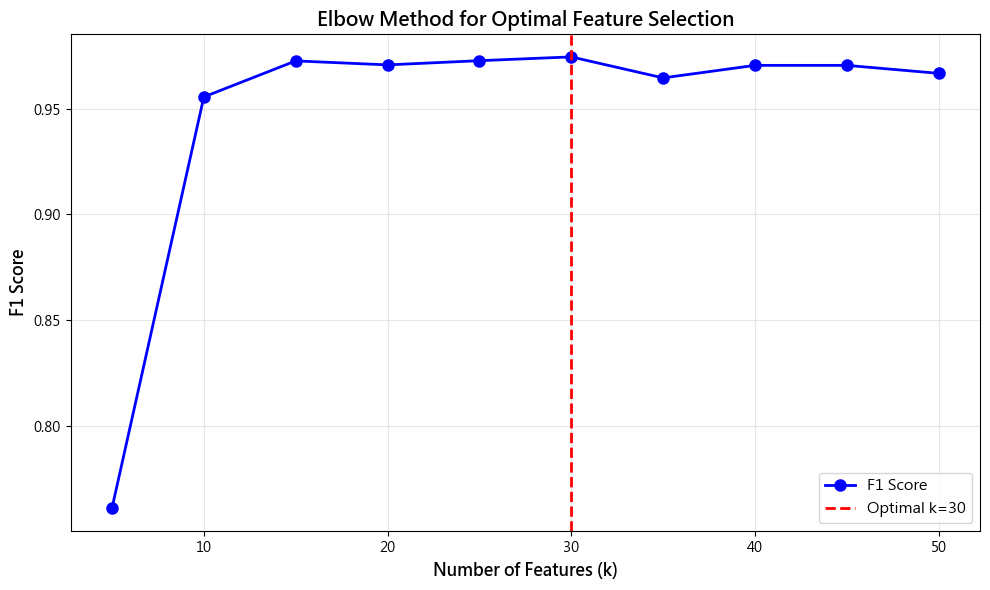


=== 特徵選擇 (保留前 30 個) ===
✓ 選擇 30 個特徵

前5個最重要特徵:
  cell_v_high_flag: 0.0755
  self_discharge_rate: 0.0728
  self_dis_high: 0.0721
  cell_v_diff: 0.0714
  soc: 0.0266

訓練集: 14439 筆
驗證集: 3609 筆
測試集: 7735 筆

=== Isolation Forest 參數優化 ===
  總共測試 48 種參數組合...
    進度: 12/48
    進度: 24/48
    進度: 36/48
    進度: 48/48

  ✓ 最佳參數 (F1=0.5390):
    n_estimators: 100
    max_samples: 512
    contamination: 0.05
    max_features: 0.3

  前5名參數組合:
 n_estimators  max_samples  contamination  max_features  precision   recall       f1  accuracy
          100          512           0.05           0.3   0.503311 0.580153 0.539007  0.927958
          100          512           0.08           0.3   0.371663 0.690840 0.483311  0.892768
          100          256           0.08           0.2   0.371560 0.618321 0.464183  0.896370
          100          512           0.12           0.3   0.312121 0.786260 0.446855  0.858687
          100          512           0.05           0.2   0.418060 0.477099 0.445633  0.9138

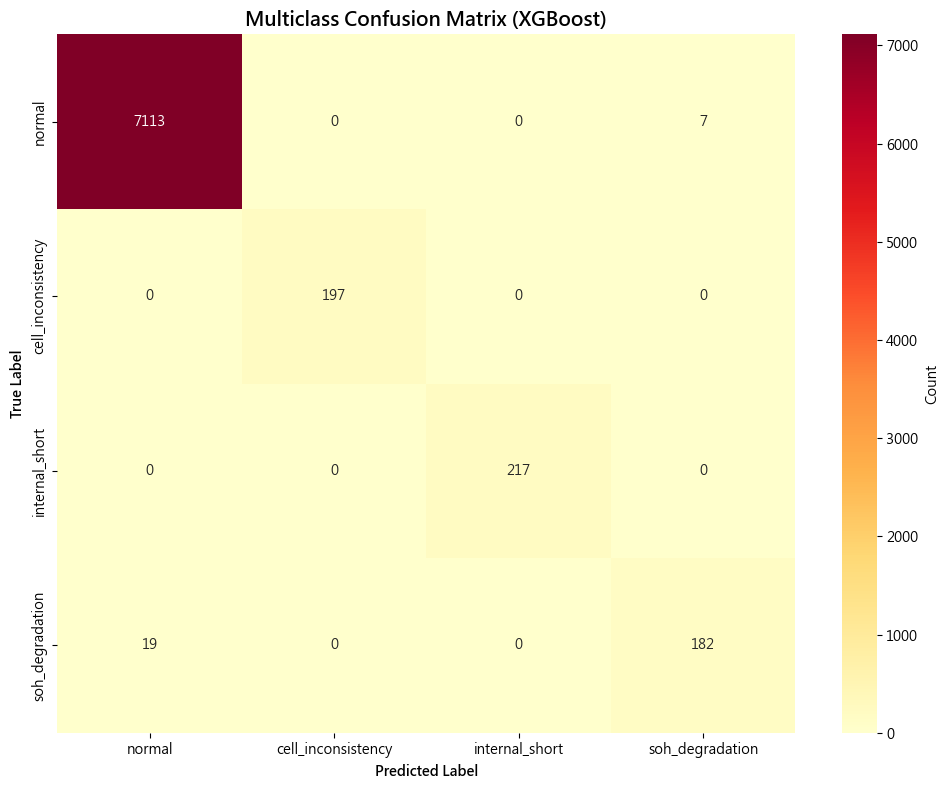


   最終結果 (Hybrid 混合檢測器)
  Precision   : 0.9934
  Recall      : 0.9740
  F1          : 0.9836
  Accuracy    : 0.9974
✓ 圖1 已保存: fig1_confusion_matrix.png


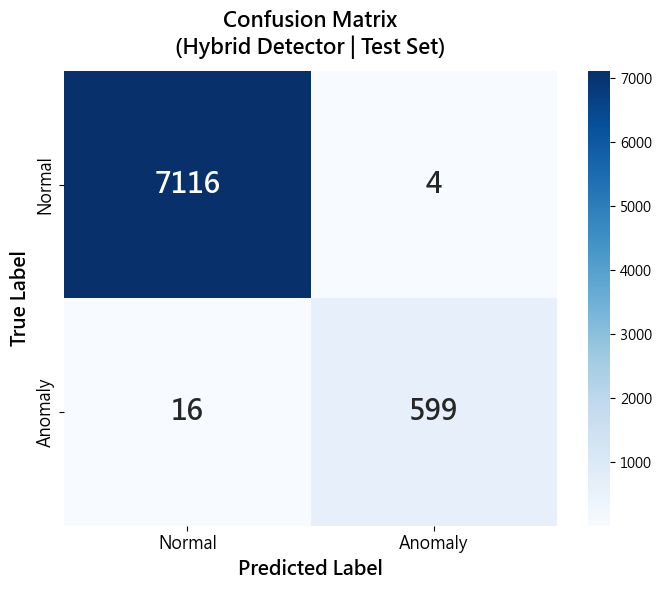

✓ 圖2 已保存: fig2_final_metrics.png


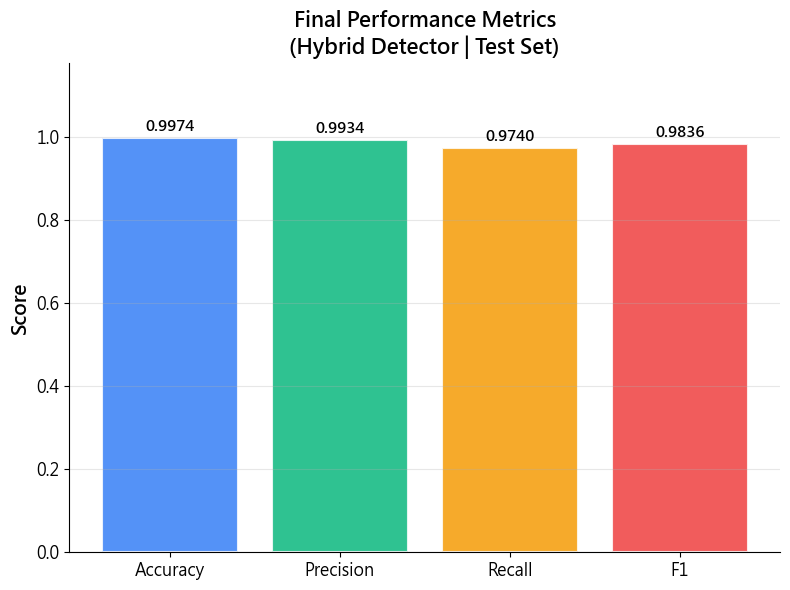

✓ 圖3 已保存: fig3_score_distribution.png


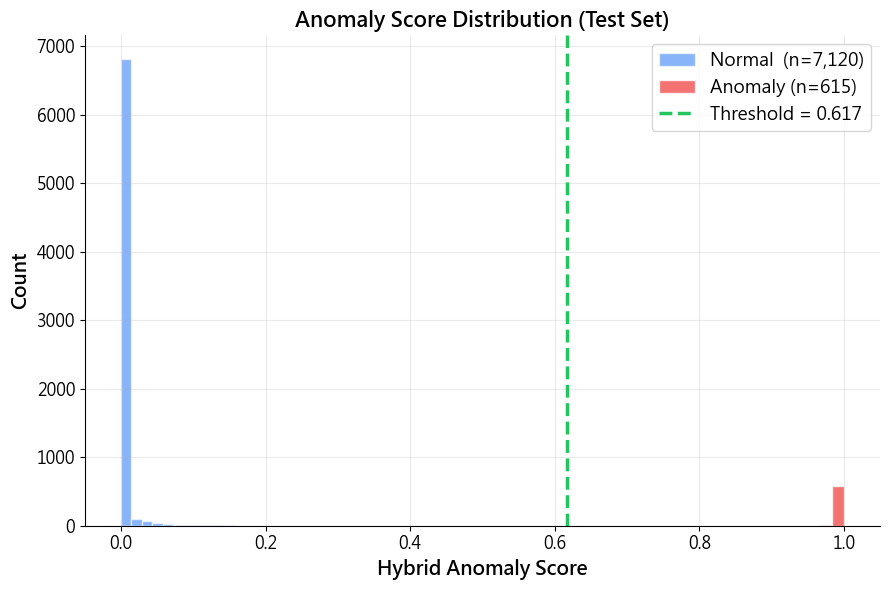

✓ 圖4 已保存: fig4_roc_curve.png


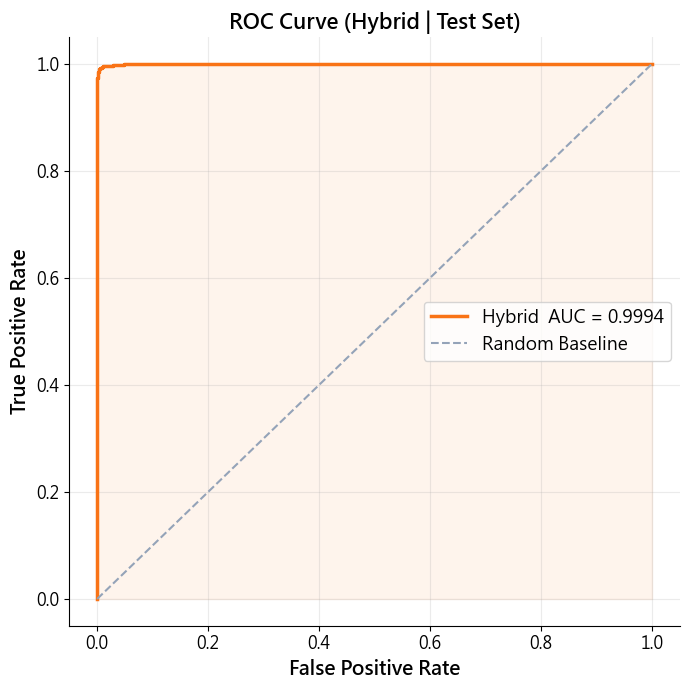

✓ 圖5 已保存: fig5_pr_curve.png


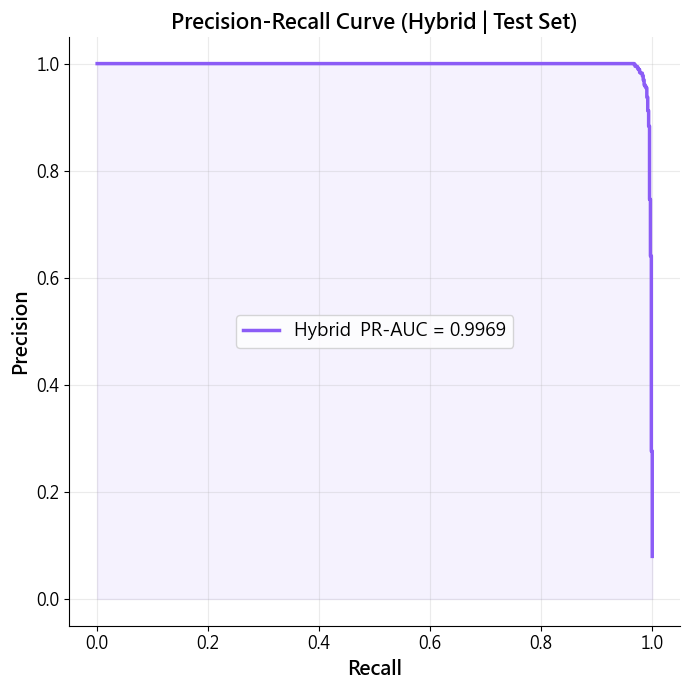

✓ 圖7 已保存: fig7_test_comparison.png


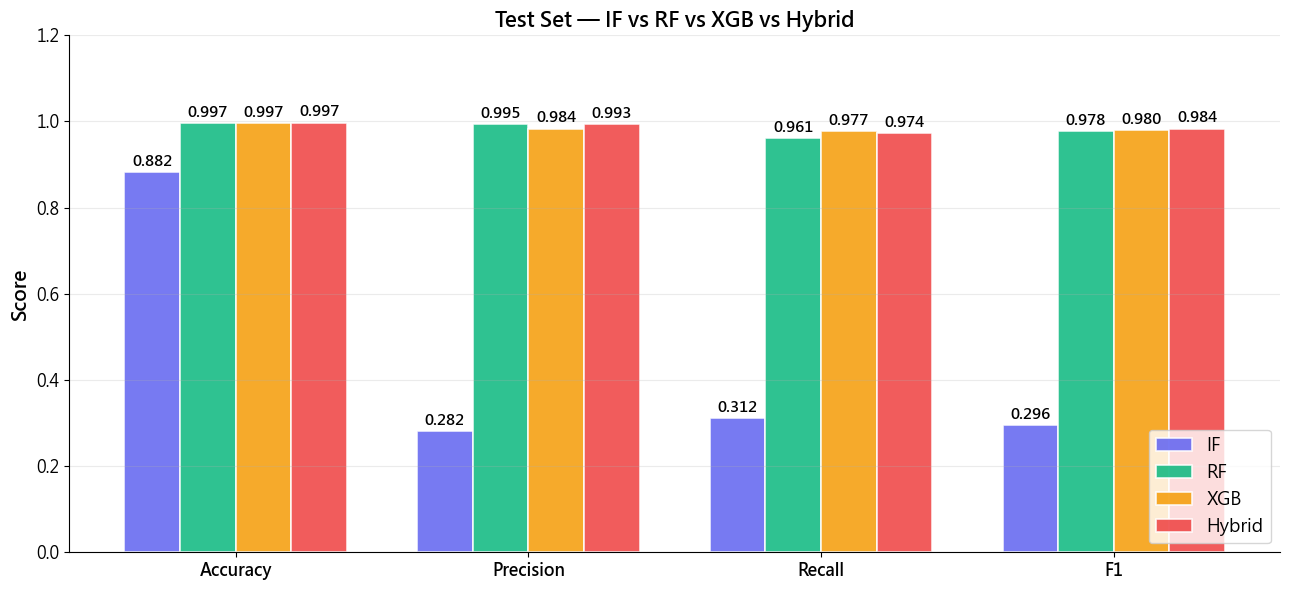

✓ 圖8 已保存: fig8_timeseries_anomaly.png


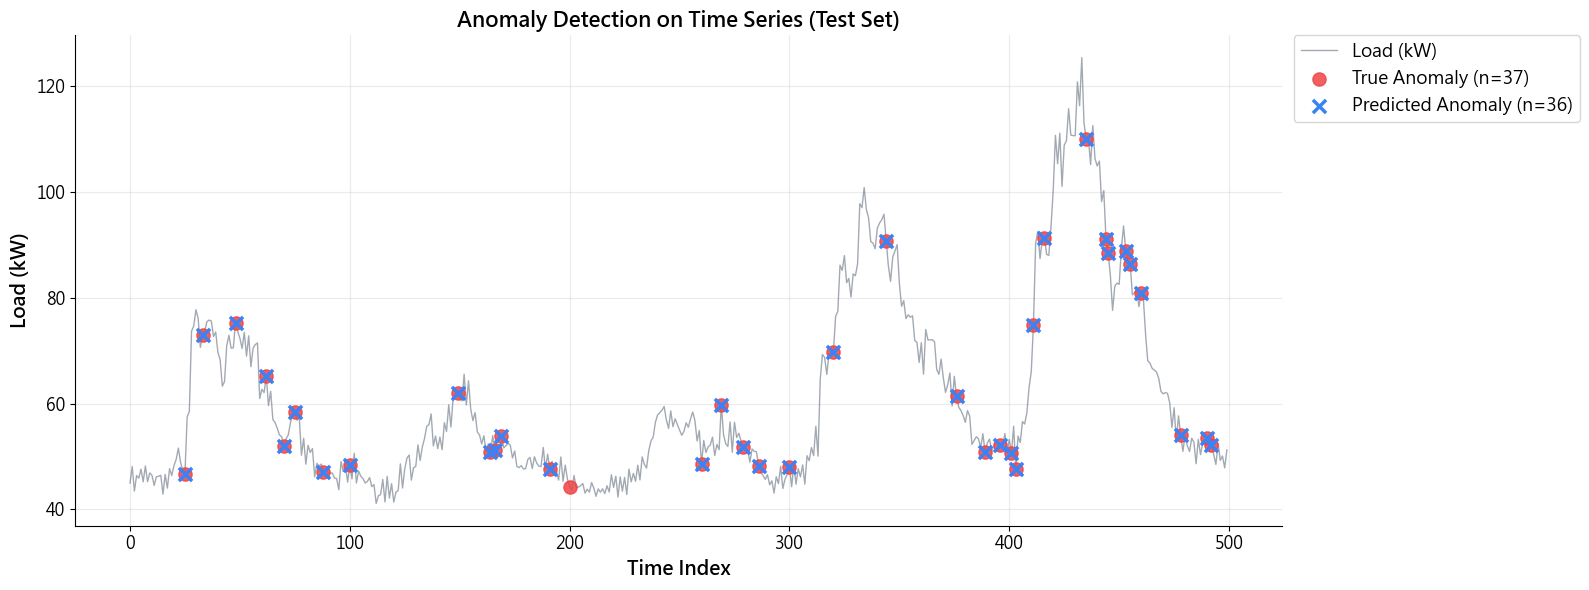


✅ 全部圖表輸出完畢

✓ 模型已存檔: c:\Users\zoe97\OneDrive\Desktop\260916數位孿生目前最終版計劃案代碼\ems_model_bundle.joblib（【階段二】即時推論會載入這份，特徵模式: 含模擬電池診斷特徵（原始模式））

   階段一總時長: 20.5 分鐘


In [20]:
df, hybrid_result, final_metrics, multiclass_result, model_bundle = main_stage1_offline_training(
    csv_folder=CSV_FOLDER,
    anomaly_rate=0.08,
    resample_to='15min',
    auto_feature_selection=True,
    use_firebase=False,      # ← 需要上傳 Firebase 時改成 True
    upload_to_fb=False,      # ← 需要上傳 Firebase 時改成 True
    use_synthetic_diagnostic_features=True,
)

## 執行區塊三：Modbus 現場診斷（強烈建議在啟動即時監測前先跑這格）

**這一格完全不需要 Firebase，也不需要先訓練模型，隨時可以獨立執行。**

先確認：
1. TCP 是否連得上
2. FC03 是否收到有效 response
3. registers 原始值 + 解碼後的實際 kW / % 數值是否合理

主表、儲能電表應該已經可以直接成功（已用現場數值驗證過）。
EMS 預設是停用狀態，這格只會顯示「⊘ 已停用」，不會嘗試連線。
若要重新測試 EMS，把上面「Modbus 端點設定」那格的 `EMS_CFG['enabled']` 改成 `True` 再重跑這一格即可。


In [21]:
def run_modbus_diagnostics():
    """單純測 TCP + Modbus 讀值是否正常，不寫 Firebase、不跑模型。"""
    print("\n" + "=" * 70)
    print("   Modbus 現場診斷")
    print("=" * 70)

    main_client, ess_client, ess_soc_client, ems_client = connect_all_modbus_clients()

    print(f"\n--- {MAIN_METER_CFG['name']} {MAIN_METER_CFG['ip']}:{MAIN_METER_CFG['port']} ---")
    try:
        value, regs = read_meter_power_kw(main_client, MAIN_METER_CFG)
        print(f"  ✓ FC03 0x{METER_POWER_SPEC['address']:04X} registers={regs} → {value:.3f} kW")
    except Exception as e:
        print(f"  ✗ {type(e).__name__}: {e}")

    print(f"\n--- {ESS_METER_CFG['name']} {ESS_METER_CFG['ip']}:{ESS_METER_CFG['port']} ---")
    try:
        value, regs = read_meter_power_kw(ess_client, ESS_METER_CFG)
        print(f"  ✓ FC03 0x{METER_POWER_SPEC['address']:04X} registers={regs} → {value:.3f} kW")
    except Exception as e:
        print(f"  ✗ {type(e).__name__}: {e}")

    print(f"\n--- {ESS_SOC_CFG['name']} {ESS_SOC_CFG['ip']}:{ESS_SOC_CFG['port']} ---")
    if not ESS_SOC_CFG.get('enabled', False):
        print("  ⊘ 已停用（ESS_SOC_CFG['enabled']=False）")
    else:
        try:
            soc, p_kw = read_ess_soc_power(ess_soc_client, ESS_SOC_CFG)
            print(f"  ✓ FC03 addr {ESS_SOC_SPEC['address']} → SOC={soc:.2f}%，"
                  f"FC03 addr {ESS_POWER_SPEC['address']} → 功率={p_kw:.3f} kW")
        except Exception as e:
            print(f"  ✗ {type(e).__name__}: {e}")

    print(f"\n--- {EMS_CFG['name']} {EMS_CFG['ip']}:{EMS_CFG['port']} ---")
    if not EMS_CFG.get('enabled', False):
        print("  ⊘ 已停用（EMS_CFG['enabled']=False）")
    else:
        try:
            status = read_ems_status(ems_client, EMS_CFG)
            print(f"  ✓ ess_power={status['ess_power']:.3f} kW, "
                  f"soc={status['soc']:.1f}%, soh={status['soh']:.1f}%")
        except Exception as e:
            print(f"  ✗ {type(e).__name__}: {e}")

    close_all_modbus_clients(main_client, ess_client, ess_soc_client, ems_client)
    print("\n診斷完成。")


run_modbus_diagnostics()



   Modbus 現場診斷
  ✓ 連線 主表 (ModbusTcpClient 192.168.1.202:502)
  ✓ 連線 儲能電表 (ModbusTcpClient 192.168.1.203:502)
  ✓ 連線 儲能主機(SOC) (ModbusTcpClient 192.168.1.200:502)
  ⊘ EMS 已停用（EMS_CFG['enabled']=False），略過連線

--- 主表 192.168.1.202:502 ---
  ✓ FC03 0x4022 registers=[18353, 1932] → 90.639 kW

--- 儲能電表 192.168.1.203:502 ---
  ✓ FC03 0x4022 registers=[50206, 8713] → -0.633 kW

--- 儲能主機(SOC) 192.168.1.200:502 ---
  ✓ FC03 addr 199 → SOC=94.60%，FC03 addr 300 → 功率=-0.640 kW

--- EMS 192.168.1.204:2000 ---
  ⊘ 已停用（EMS_CFG['enabled']=False）

診斷完成。


## 執行區塊四：【階段二】線上即時運行

**執行這格之前，強烈建議先跑過上面的「Modbus 現場診斷」格，確認主表/儲能電表/儲能主機(SOC) 都 GOOD。**

### v5：SOC 改用邱老師實驗室驗證過的來源，EMS 程式碼保留但停用

`ESS_SOC_CFG['enabled'] = True`：SOC 從 `192.168.1.200:502` 位址 199 讀取（跟邱老師實驗室
`ems_other_laboratory_renew.py` 用的是同一套後台、已驗證可穩定讀到）。

`EMS_CFG['enabled'] = False`：**EMS 相關的程式碼（`EMS_KAC50DP_LEVEL1_PROFILE`、
`read_ems_status`、EMS 連線）完全沒有刪除、原封不動保留**，之後若排查通了原本的 EMS，
只要把這個布林值改成 `True`，它讀到的值會優先覆蓋 `ess_power`/`soc`，其他程式碼都不用動。

在目前設定下：
- **主表、儲能電表、儲能主機(SOC) 照常讀取，正常寫入 Firebase**（`before_load` / `ess_power` / `after_load` / `soc`）。
- 只有在 `ESS_SOC_CFG` 也讀取失敗、且 EMS 也停用時，`soc` 才會維持 `None`，
  寫進 Firebase 時明確標成 `EMS_DISABLED`，不會偷偷補 0 或沿用上一筆冒充。
- 有 SOC 且累積資料足夠時才會跑模型推論；沒有 SOC 時 `anomaly_type` 標成 `EMS_DISABLED_NO_MODEL`。

### 執行

```python
ref = init_firebase(FIREBASE_CRED_JSON_PATH)

run_realtime_loop(
    ref,
    model_bundle=model_bundle,
    poll_interval_sec=60,
    align_to_clock=True,
    align_second_offset=10,
    max_iterations=None,        # 持續跑，Ctrl+C（或 Jupyter 的 Stop 方塊）中止
    upload_to_firebase=True,    # 主表/儲能電表/儲能主機(SOC) 資料正常寫入 Firebase
)
```


In [24]:
ref = init_firebase(r"C:\Users\zoe97\OneDrive\Desktop\260916數位孿生目前最終版計劃案代碼\essssimulation3-firebase-adminsdk-fbsvc-0d8253860b.json")
ref.child('ems_data').child('2026-09-17').delete()
print('已刪除 2026-09-17 的資料')


=== Firebase 初始化 ===
📊 專案 ID: essssimulation3
🔗 資料庫 URL: https://essssimulation3-default-rtdb.asia-southeast1.firebasedatabase.app/
✓ Firebase 連接成功!
已刪除 2026-09-17 的資料


In [ ]:
# 主表/儲能電表正常讀取並寫入 Firebase；EMS 程式碼保留但目前停用（見上方 EMS_CFG['enabled']）
ref = init_firebase(r"C:\Users\zoe97\OneDrive\Desktop\260916數位孿生目前最終版計劃案代碼\essssimulation3-firebase-adminsdk-fbsvc-0d8253860b.json")

run_realtime_loop(
    ref,
    model_bundle=model_bundle,
    poll_interval_sec=60,
    align_to_clock=True,
    align_second_offset=10,   # 對齊到每分鐘第 10 秒；改成 0 就是整分鐘
    max_iterations=None,      # 持續跑，Ctrl+C（或按 Jupyter 的 Stop 方塊）中止
    upload_to_firebase=True,
)

# 只想先測試看數據、還不想寫進 Firebase 的話，改用這行（先把上面那段註解掉）：
# run_realtime_loop(ref, model_bundle=model_bundle, poll_interval_sec=60,
#                    align_to_clock=True, align_second_offset=10,
#                    max_iterations=5, upload_to_firebase=False)



=== Firebase 初始化 ===
📊 專案 ID: essssimulation3
🔗 資料庫 URL: https://essssimulation3-default-rtdb.asia-southeast1.firebasedatabase.app/
✓ Firebase 連接成功!

   【階段二】即時 Modbus TCP 監測啟動
   Buffer 涵蓋時間跨度: ~6.5 小時（最多保留 400 筆 raw 輪詢）
   推論前至少累積 raw 筆數: 30
   SOC 來源: 儲能主機 192.168.1.200
  ✓ 連線 主表 (ModbusTcpClient 192.168.1.202:502)
  ✓ 連線 儲能電表 (ModbusTcpClient 192.168.1.203:502)
  ✓ 連線 儲能主機(SOC) (ModbusTcpClient 192.168.1.200:502)
  ⊘ EMS 已停用（EMS_CFG['enabled']=False），略過連線
   對齊時鐘模式：等待到 11:55:10 才開始第一次讀值...
[11:55] before=101.2kW after=101.8kW ESS=-0.64kW SOC=94.6% → 累積資料中 (1/30)
[11:56] before=85.6kW after=86.3kW ESS=-0.64kW SOC=94.6% → 累積資料中 (2/30)
[11:57] before=82.9kW after=83.5kW ESS=-0.64kW SOC=94.6% → 累積資料中 (3/30)
